# GNN Spatio-Temporel — Prévision des Injections de Gaz (4 Wells, 24h)

**Objectif** : Prédire les injections de gaz des 4 wells sur les 24h futures  
à partir des 72h d'historique et de la structure du réseau de gaz belge.

**Pipeline** :
1. Exploration des fichiers Excel
2. Lecture et concaténation des séries temporelles
3. Construction des features nodales et d'arête
4. Normalisation
5. Fenêtres temporelles glissantes
6. Dataset / DataLoader
7. Modèle GNN spatio-temporel (encoder → message passing → attention temporelle → decoder)
8. Entraînement avec early stopping
9. Évaluation et diagnostics d'alignement
10. Visualisations et comparaison baseline

---


## Cellule 1 — Imports

In [1]:
# ============================================================
# CELL 1 : IMPORTS
# ============================================================
# Librairies standard
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy

# Sklearn pour la normalisation
from sklearn.preprocessing import StandardScaler

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé  : {DEVICE}")


PyTorch version : 2.5.1
CUDA disponible : True
Device utilisé  : cuda


## Cellule 2 — Configuration globale (tous les hyperparamètres ici)

In [7]:
# ============================================================
# CELL 2 : CONFIGURATION GLOBALE
# Tous les hyperparamètres sont définis ici pour faciliter
# les expérimentations sans toucher au reste du code.
# ============================================================

# --- Chemins des fichiers Excel ---
DATA_DIR = ""   # Adapter si nécessaire
PATH_NETWORK  = os.path.join(DATA_DIR, "./Gas Network Data.xlsx")
PATH_DISTRIB  = os.path.join(DATA_DIR, "./input/Gas Cons Distrib.xlsx")
PATH_EXPORT   = os.path.join(DATA_DIR, "./input/Gas Cons Export.xlsx")
PATH_IND      = os.path.join(DATA_DIR, "./input/Gas Cons Ind.xlsx")
PATH_DECISION = os.path.join(DATA_DIR, "./output/Decision_variablesRU.xlsx")

# --- Structure du réseau ---
N_NODES   = 28    # Nombre de noeuds
N_WELLS   = 4     # Nombre de wells
# Indices 0-based des noeuds wells (facilement modifiable)
WELL_IDX  = [0, 4, 16, 17]  # noeuds 1, 5, 17, 18 en 1-based

# --- Fenêtres temporelles ---
HIST_HOURS    = 72    # Longueur de la fenêtre d'entrée
HORIZON_HOURS = 24    # Longueur de l'horizon de prévision
BLOCK         = HIST_HOURS + HORIZON_HOURS  # = 96 heures
STRIDE        = 6     # Pas de glissement en heures

# --- Split train/val/test (par proportion de fenêtres) ---
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# test = 1 - TRAIN_FRAC - VAL_FRAC = 0.15

# --- DataLoader ---
BATCH_SIZE = 32
NUM_WORKERS = 0   # Mettre 4 si on a des CPU cores libres

# --- Features (flags pour activer/désactiver) ---
USE_GLOBAL_CONS  = True   # Ajouter les consommations globales répétées sur tous les noeuds
USE_G_NODE       = True   # Ajouter l'historique g sur les noeuds wells (0 ailleurs)
USE_SIN_COS_TIME = False  # Encodage sin/cos de l'heure et du jour de l'année

# --- Features d'arête ---
# Options : 'dynamic', 'static', 'both'
EDGE_FEATURE_MODE = 'both'

# Direction du débit q sur les arêtes bidirectionnelles
# Options : 'abs' (abs(q) pour les deux) ou 'signed' (q fwd, -q bwd)
Q_DIRECTION_MODE  = 'signed'

# --- Targets ---
# Options : 'absolute' ou 'delta' (différence depuis la dernière heure observée)
TARGET_MODE = 'absolute'

# --- Modèle ---
HIDDEN_DIM    = 64     # Dimension des couches cachées
N_MP_LAYERS   = 2     # Nombre de couches de message passing
N_ATTN_HEADS  = 4     # Nombre de têtes d'attention temporelle
DROPOUT       = 0.1   # Dropout

# Options : 'attention' ou 'gru'
TEMPORAL_MODE = 'attention'

# --- Entraînement ---
LR           = 5e-4
WEIGHT_DECAY = 1e-3
EPOCHS       = 300
PATIENCE     = 20     # Early stopping
GRAD_CLIP    = 1.0    # Gradient clipping max norm

# Loss : 'mse' ou 'huber'
LOSS_MODE    = 'mse'
HUBER_DELTA  = 1.0   # Utilisé si LOSS_MODE == 'huber'

print("Configuration chargée.")
print(f"  HIST_HOURS={HIST_HOURS}, HORIZON_HOURS={HORIZON_HOURS}, BLOCK={BLOCK}, STRIDE={STRIDE}")
print(f"  WELL_IDX={WELL_IDX}, N_NODES={N_NODES}, N_WELLS={N_WELLS}")
print(f"  EDGE_FEATURE_MODE={EDGE_FEATURE_MODE}, Q_DIRECTION_MODE={Q_DIRECTION_MODE}")
print(f"  TEMPORAL_MODE={TEMPORAL_MODE}, HIDDEN_DIM={HIDDEN_DIM}")


Configuration chargée.
  HIST_HOURS=72, HORIZON_HOURS=24, BLOCK=96, STRIDE=6
  WELL_IDX=[0, 4, 16, 17], N_NODES=28, N_WELLS=4
  EDGE_FEATURE_MODE=both, Q_DIRECTION_MODE=signed
  TEMPORAL_MODE=attention, HIDDEN_DIM=64


## Partie A — Exploration des fichiers Excel

### Cellule 3 — Gas_Network_Data.xlsx

In [8]:
# ============================================================
# CELL 3 : EXPLORATION DE Gas_Network_Data.xlsx
# On affiche chaque feuille disponible et ses premières lignes.
# Aucune hypothèse silencieuse : tout est affiché.
# ============================================================

xl_network = pd.ExcelFile(PATH_NETWORK)
print(f"Feuilles dans Gas_Network_Data.xlsx ({len(xl_network.sheet_names)}) :")
for s in xl_network.sheet_names:
    df_tmp = xl_network.parse(s)
    print(f"  '{s}' -> shape={df_tmp.shape}, colonnes={list(df_tmp.columns)}")

print()
print("=== Feuille 'Nodes' ===")
df_nodes_raw = xl_network.parse("Nodes")
print(df_nodes_raw.to_string())

print()
print("=== Feuille 'Pipelines' ===")
df_pipes_raw = xl_network.parse("Pipelines")
print(df_pipes_raw.to_string())


Feuilles dans Gas_Network_Data.xlsx (8) :
  'Nodes' -> shape=(28, 6), colonnes=['Gas Node', 'Res_Load_share_%', 'Ind_Load_share_%', 'Exp_Load_share_%', 'Pr_min [bar]', 'Pr_max [bar]']
  'Pipelines' -> shape=(33, 10), colonnes=['Pipeline', 'From node', 'To node', 'Natural gas flow constant [MNm3/(bar*h)2]', 'Compressor factor', 'High Linepack', 'Initial linepack [MNm3]', 'Linepack constant [MNm3/bar]', 'Estimated lenght [km]', 'Linepack constant quantifies']
  'Check' -> shape=(33, 8), colonnes=['Natural gas flow constant [MNm3/(bar*h)2]', 'Estimated lenght [km]', 'Linepack constant [MNm3/bar]', 'T (K)', 'Density (kg/m3)', 'Compressibility', 'p0 (bar)', 'T0 (K)']
  'Well' -> shape=(4, 10), colonnes=['Gas node', 'Gmax [MNm3/h]', 'Day-ahead offer price [€/MNm3]', 'Spot Market TTF Q4 2024 :', 'Unnamed: 4', 'Unnamed: 5', 'GCV  moyen décembre :', 'Unnamed: 7', 'Unnamed: 8', 'OLD Day-ahead offer price (€/Mm3)']
  'GasWellMap' -> shape=(28, 4), colonnes=['Well1', 'Well2', 'Well4', 'Well5']
  '

### Cellule 4 — Decision_variablesRU.xlsx

In [9]:
# ============================================================
# CELL 4 : EXPLORATION DE Decision_variablesRU.xlsx
# On identifie automatiquement les feuilles g-*, q-*, pr-*, etc.
# ============================================================

xl_dec = pd.ExcelFile(PATH_DECISION)
all_sheets = xl_dec.sheet_names
print(f"Nombre total de feuilles : {len(all_sheets)}")

# Détection automatique des feuilles par préfixe
prefixes = ['g-', 'q-', 'pr-', 'p-', 'NMAE-', 'Time-']
sheet_map = {pfx: [] for pfx in prefixes}
for s in all_sheets:
    for pfx in prefixes:
        if s.startswith(pfx):
            sheet_map[pfx].append(s)
            break

for pfx, sheets in sheet_map.items():
    print(f"  Préfixe '{pfx}' : {len(sheets)} feuilles -> {sheets[:3]}{'...' if len(sheets) > 3 else ''}")

# Vérification que g et q ont exactement 12 mois
assert len(sheet_map['g-']) == 12, f"Attendu 12 feuilles g-, trouvé {len(sheet_map['g-'])}"
assert len(sheet_map['q-']) == 12, f"Attendu 12 feuilles q-, trouvé {len(sheet_map['q-'])}"
print("\n✓ 12 feuilles g- et q- confirmées")

# Aperçu de g-01-2024
df_g_jan = xl_dec.parse('g-01-2024', index_col=0)
print(f"\ng-01-2024: shape={df_g_jan.shape}")
print(f"  Colonnes: {list(df_g_jan.columns)}")
print(df_g_jan.head(3).to_string())

# Aperçu de q-01-2024
df_q_jan = xl_dec.parse('q-01-2024', index_col=0)
print(f"\nq-01-2024: shape={df_q_jan.shape}")
print(f"  Colonnes: {list(df_q_jan.columns)}")
print(df_q_jan.head(3).to_string())


Nombre total de feuilles : 72
  Préfixe 'g-' : 12 feuilles -> ['g-01-2024', 'g-02-2024', 'g-03-2024']...
  Préfixe 'q-' : 12 feuilles -> ['q-01-2024', 'q-02-2024', 'q-03-2024']...
  Préfixe 'pr-' : 12 feuilles -> ['pr-01-2024', 'pr-02-2024', 'pr-03-2024']...
  Préfixe 'p-' : 12 feuilles -> ['p-01-2024', 'p-02-2024', 'p-03-2024']...
  Préfixe 'NMAE-' : 12 feuilles -> ['NMAE-01-2024', 'NMAE-02-2024', 'NMAE-03-2024']...
  Préfixe 'Time-' : 12 feuilles -> ['Time-01-2024', 'Time-02-2024', 'Time-03-2024']...

✓ 12 feuilles g- et q- confirmées

g-01-2024: shape=(744, 4)
  Colonnes: [0, 1, 2, 3]
          0         1         2         3
0  2.163437  0.344229  1.371083  0.078159
1  2.394095  0.444444  1.333333  0.228159
2  2.113282  0.444444  1.160831  0.115398

q-01-2024: shape=(744, 33)
  Colonnes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
         0         1         2         3         4         5         6    

### Cellule 5 — Exploration des fichiers de consommation

In [10]:
# ============================================================
# CELL 5 : EXPLORATION DES FICHIERS DE CONSOMMATION
# Distribution, Export, Industrielle : même structure mensuelle.
# ============================================================

for path, name in [(PATH_DISTRIB, "Distribution"), (PATH_EXPORT, "Export"), (PATH_IND, "Industrielle")]:
    xl_tmp = pd.ExcelFile(path)
    sheets_tmp = [s for s in xl_tmp.sheet_names if s != 'year']
    print(f"\n{name} ({path.split('/')[-1]}) : {len(sheets_tmp)} feuilles mensuelles")
    df_ex = xl_tmp.parse(sheets_tmp[0])
    print(f"  Colonnes : {list(df_ex.columns)}")
    print(f"  Dtype DateHeure : {df_ex.iloc[:,0].dtype}")
    print(df_ex.head(2).to_string())



Distribution (Gas Cons Distrib.xlsx) : 12 feuilles mensuelles
  Colonnes : ['Date Time', 'Physical Flow (kWh)', 'Physical Flow (MNm3)', 'GCV (kwh/Nm3)']
  Dtype DateHeure : datetime64[ns]
            Date Time  Physical Flow (kWh)  Physical Flow (MNm3)  GCV (kwh/Nm3)
0 2024-01-01 00:00:00              7071850              0.613663         11.524
1 2024-01-01 01:00:00              6946199              0.602864         11.522

Export (Gas Cons Export.xlsx) : 12 feuilles mensuelles
  Colonnes : ['Date Time', 'Physical Flow VIP BENE (kWh)', 'Physical Flow Blaregnies L (kWh)', 'Physical Flow Bras-Petange (kWh)', 'Physical Flow VIP THE-ZPT (kWh)', 'GCV (kwh/Nm3)', 'Physical Flow (MNm3)']
  Dtype DateHeure : datetime64[ns]
            Date Time  Physical Flow VIP BENE (kWh)  Physical Flow Blaregnies L (kWh)  Physical Flow Bras-Petange (kWh)  Physical Flow VIP THE-ZPT (kWh)  GCV (kwh/Nm3)  Physical Flow (MNm3)
0 2024-01-01 00:00:00                   6574506.477                               0

## Partie B — Lecture et concaténation des séries temporelles

### Cellule 6 — Concaténation des consommations

In [11]:
# ============================================================
# CELL 6 : LECTURE ET CONCATÉNATION DES CONSOMMATIONS
# On parcourt les 12 feuilles mensuelles de chaque fichier
# et on concatène en une série annuelle de 8784 heures.
# Colonne utilisée : 'Physical Flow (MNm3)'
# ============================================================

def load_monthly_timeseries(path, col='Physical Flow (MNm3)', exclude_sheet='year'):
    """Charge et concatène les feuilles mensuelles d'un fichier Excel.
    
    Returns
    -------
    series : np.ndarray de shape (T,)
        Série temporelle annuelle.
    dates : pd.DatetimeIndex
        Index temporel correspondant.
    """
    xl = pd.ExcelFile(path)
    monthly = [s for s in xl.sheet_names if s != exclude_sheet]
    # Tri explicite par ordre alphabétique (01-2024 < 02-2024 < ... < 12-2024)
    monthly_sorted = sorted(monthly)
    print(f"  Feuilles détectées ({len(monthly_sorted)}) : {monthly_sorted}")
    
    dfs = []
    for sh in monthly_sorted:
        df = xl.parse(sh)
        # Vérification colonne cible
        if col not in df.columns:
            raise ValueError(f"Colonne '{col}' introuvable dans '{sh}'. "
                             f"Colonnes disponibles : {list(df.columns)}")
        # Vérification colonne datetime
        date_col = df.columns[0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col).sort_index()
        dfs.append(df[[col]])
    
    full = pd.concat(dfs, axis=0)
    # Vérification : pas de doublon, pas de trou
    assert full.index.is_monotonic_increasing, "Index temporel non monotone !"
    dups = full.index.duplicated().sum()
    if dups > 0:
        print(f"  AVERTISSEMENT : {dups} doublons d'index détectés, suppression...")
        full = full[~full.index.duplicated(keep='first')]
    
    return full[col].values, full.index

print("Chargement consommation Distribution...")
cons_distrib, dates_distrib = load_monthly_timeseries(PATH_DISTRIB)
print(f"  -> shape={cons_distrib.shape}, range=[{cons_distrib.min():.4f}, {cons_distrib.max():.4f}] MNm3")

print("\nChargement consommation Export...")
cons_export, dates_export = load_monthly_timeseries(PATH_EXPORT)
print(f"  -> shape={cons_export.shape}, range=[{cons_export.min():.4f}, {cons_export.max():.4f}] MNm3")

print("\nChargement consommation Industrielle...")
cons_ind, dates_ind = load_monthly_timeseries(PATH_IND)
print(f"  -> shape={cons_ind.shape}, range=[{cons_ind.min():.4f}, {cons_ind.max():.4f}] MNm3")

# Vérification alignement temporel entre les 3 séries
T_distrib = len(cons_distrib)
T_export  = len(cons_export)
T_ind     = len(cons_ind)
assert T_distrib == T_export == T_ind, \
    f"Longueurs incohérentes : distrib={T_distrib}, export={T_export}, ind={T_ind}"
T_CONS = T_distrib
print(f"\n✓ Longueurs cohérentes : T={T_CONS} heures")

# Vérification bissextile 2024 = 8784 heures
if T_CONS != 8784:
    print(f"  AVERTISSEMENT : attendu 8784h pour 2024, obtenu {T_CONS}h")
else:
    print(f"✓ 8784 heures (année bissextile 2024 confirmée)")

# Vérification que les index datetime correspondent
if not dates_distrib.equals(dates_export):
    print("AVERTISSEMENT : index datetime Distribution ≠ Export")
if not dates_distrib.equals(dates_ind):
    print("AVERTISSEMENT : index datetime Distribution ≠ Industrielle")


Chargement consommation Distribution...
  Feuilles détectées (12) : ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024']
  -> shape=(8784,), range=[0.0001, 2.5500] MNm3

Chargement consommation Export...
  Feuilles détectées (12) : ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024']
  -> shape=(8784,), range=[0.9350, 3.8862] MNm3

Chargement consommation Industrielle...
  Feuilles détectées (12) : ['01-2024', '02-2024', '03-2024', '04-2024', '05-2024', '06-2024', '07-2024', '08-2024', '09-2024', '10-2024', '11-2024', '12-2024']
  -> shape=(8784,), range=[0.3036, 0.5241] MNm3

✓ Longueurs cohérentes : T=8784 heures
✓ 8784 heures (année bissextile 2024 confirmée)


### Cellule 7 — Concaténation des injections g et débits q

In [12]:
# ============================================================
# CELL 7 : LECTURE ET CONCATÉNATION DE g (injections wells)
#           ET q (débits pipelines)
# g-MM-2024 : T_month lignes × 4 colonnes (4 wells)
# q-MM-2024 : T_month lignes × 33 colonnes (33 pipelines)
# On trie explicitement par numéro de mois.
# ============================================================

def load_decision_variable(xl_file, prefix, expected_cols=None):
    """Charge et concatène les feuilles 'prefix-MM-2024' sur l'année.
    
    Parameters
    ----------
    xl_file : pd.ExcelFile
    prefix  : str, ex: 'g' ou 'q'
    expected_cols : int ou None, nombre de colonnes attendu (hors index)
    
    Returns
    -------
    arr : np.ndarray de shape (T, C)
    """
    sheets = sorted([s for s in xl_file.sheet_names if s.startswith(f'{prefix}-')])
    print(f"  Préfixe '{prefix}' : {len(sheets)} feuilles -> {sheets}")
    
    dfs = []
    for sh in sheets:
        df = xl_file.parse(sh, index_col=0)  # première colonne = index temporel (0..N-1)
        if expected_cols is not None:
            assert df.shape[1] == expected_cols, \
                f"'{sh}' : attendu {expected_cols} colonnes, obtenu {df.shape[1]}"
        dfs.append(df)
    
    full = pd.concat(dfs, axis=0).reset_index(drop=True)
    return full.values  # shape (T, C)

print("Chargement des injections g...")
g_full = load_decision_variable(xl_dec, 'g', expected_cols=N_WELLS)
print(f"  g_full shape : {g_full.shape}   (attendu ({T_CONS}, {N_WELLS}))")
assert g_full.shape == (T_CONS, N_WELLS), f"Shape g incorrecte : {g_full.shape}"
print(f"  g range : [{g_full.min():.4f}, {g_full.max():.4f}]")

print("\nChargement des débits q...")
N_PIPES = 33  # vérifié en exploration
q_full = load_decision_variable(xl_dec, 'q', expected_cols=N_PIPES)
print(f"  q_full shape : {q_full.shape}   (attendu ({T_CONS}, {N_PIPES}))")
assert q_full.shape == (T_CONS, N_PIPES), f"Shape q incorrecte : {q_full.shape}"
print(f"  q range : [{q_full.min():.4f}, {q_full.max():.4f}]")

# Vérification finale d'alignement temporel
assert g_full.shape[0] == T_CONS, "g_full n'a pas le bon T"
assert q_full.shape[0] == T_CONS, "q_full n'a pas le bon T"
T = T_CONS  # T global pour la suite
print(f"\n✓ T global = {T} heures, toutes séries alignées")


Chargement des injections g...
  Préfixe 'g' : 12 feuilles -> ['g-01-2024', 'g-02-2024', 'g-03-2024', 'g-04-2024', 'g-05-2024', 'g-06-2024', 'g-07-2024', 'g-08-2024', 'g-09-2024', 'g-10-2024', 'g-11-2024', 'g-12-2024']
  g_full shape : (8784, 4)   (attendu (8784, 4))
  g range : [0.0000, 4.0000]

Chargement des débits q...
  Préfixe 'q' : 12 feuilles -> ['q-01-2024', 'q-02-2024', 'q-03-2024', 'q-04-2024', 'q-05-2024', 'q-06-2024', 'q-07-2024', 'q-08-2024', 'q-09-2024', 'q-10-2024', 'q-11-2024', 'q-12-2024']
  q_full shape : (8784, 33)   (attendu (8784, 33))
  q range : [0.0000, 4.0000]

✓ T global = 8784 heures, toutes séries alignées


## Partie C — Construction des features nodales

### Cellule 8 — Features statiques du réseau

In [13]:
# ============================================================
# CELL 8 : FEATURES STATIQUES DES NOEUDS
# On extrait les parts de consommation résidentielle, industrielle
# et export depuis la feuille Nodes.
# Les noeuds sont 1-based dans le fichier -> conversion 0-based.
# ============================================================

df_nodes = df_nodes_raw.copy()

# Vérification du nombre de noeuds
assert len(df_nodes) == N_NODES, \
    f"Attendu {N_NODES} noeuds, trouvé {len(df_nodes)}"

# Colonnes attendues
col_node = 'Gas Node'
col_res  = 'Res_Load_share_%'
col_ind  = 'Ind_Load_share_%'
col_exp  = 'Exp_Load_share_%'
col_prmin = 'Pr_min [bar]'
col_prmax = 'Pr_max [bar]'

for col in [col_node, col_res, col_ind, col_exp]:
    assert col in df_nodes.columns, f"Colonne manquante : '{col}'"

# Tri par numéro de noeud pour garantir l'ordre 1..28
df_nodes = df_nodes.sort_values(col_node).reset_index(drop=True)

# Extraction des shares (shape = [N_NODES])
res_share = df_nodes[col_res].values.astype(np.float32)   # fraction résidentielle par noeud
ind_share = df_nodes[col_ind].values.astype(np.float32)   # fraction industrielle
exp_share = df_nodes[col_exp].values.astype(np.float32)   # fraction export

print("Shares nodales extraites :")
print(f"  res_share : sum={res_share.sum():.4f} (attendu ~1.0)")
print(f"  ind_share : sum={ind_share.sum():.4f} (attendu ~1.0)")
print(f"  exp_share : sum={exp_share.sum():.4f} (attendu ~1.0)")
print()

# Affichage des premières valeurs pour vérification visuelle
for i in range(N_NODES):
    node_id = df_nodes.loc[i, col_node]
    is_well = "(WELL)" if i in WELL_IDX else ""
    print(f"  Noeud {i:2d} (id={node_id:2d}) | res={res_share[i]:.4f} | "
          f"ind={ind_share[i]:.4f} | exp={exp_share[i]:.4f} {is_well}")

# Vecteurs is_well et node_type (pour usage futur)
is_well_flag = np.zeros(N_NODES, dtype=np.float32)
is_well_flag[WELL_IDX] = 1.0
print(f"\nWell flags : {is_well_flag}")


Shares nodales extraites :
  res_share : sum=1.0278 (attendu ~1.0)
  ind_share : sum=1.0000 (attendu ~1.0)
  exp_share : sum=1.0000 (attendu ~1.0)

  Noeud  0 (id= 1) | res=0.0000 | ind=0.0000 | exp=0.0000 (WELL)
  Noeud  1 (id= 2) | res=0.0556 | ind=0.1053 | exp=0.0000 
  Noeud  2 (id= 3) | res=0.0556 | ind=0.0526 | exp=0.0000 
  Noeud  3 (id= 4) | res=0.0556 | ind=0.0526 | exp=0.0000 
  Noeud  4 (id= 5) | res=0.0000 | ind=0.0000 | exp=0.0000 (WELL)
  Noeud  5 (id= 6) | res=0.0000 | ind=0.0000 | exp=0.0000 
  Noeud  6 (id= 7) | res=0.0000 | ind=0.0000 | exp=0.0000 
  Noeud  7 (id= 8) | res=0.0833 | ind=0.1579 | exp=0.0000 
  Noeud  8 (id= 9) | res=0.0000 | ind=0.0000 | exp=0.2000 
  Noeud  9 (id=10) | res=0.0833 | ind=0.0000 | exp=0.0000 
  Noeud 10 (id=11) | res=0.0333 | ind=0.1053 | exp=0.0000 
  Noeud 11 (id=12) | res=0.0333 | ind=0.1053 | exp=0.0000 
  Noeud 12 (id=13) | res=0.0333 | ind=0.0526 | exp=0.0000 
  Noeud 13 (id=14) | res=0.0333 | ind=0.0526 | exp=0.0000 
  Noeud 14 (id

### Cellule 9 — Construction des features nodales dynamiques

In [14]:
# ============================================================
# CELL 9 : FEATURES NODALES DYNAMIQUES
# Pour chaque heure t, et chaque noeud n :
#   X_cons[t, n, 0] = res_share[n] * cons_distrib[t]  (consommation résidentielle au noeud n à t)
#   X_cons[t, n, 1] = ind_share[n] * cons_ind[t]      (consommation industrielle au noeud n à t)
#   X_cons[t, n, 2] = exp_share[n] * cons_export[t]   (consommation export au noeud n à t)
#
# Optionnellement :
#   X_global[t, n, :] = [cons_distrib[t], cons_ind[t], cons_export[t]]  (mêmes valeurs pour tous les noeuds)
#   g_node[t, n, 0] = g_full[t, j] si n est le j-ème well, 0 sinon
#
# Résultat final : X_full de shape [T, N, F_node]
# ============================================================

# --- X_cons : [T, N, 3] ---
# Broadcasting : (T, 1) * (N,) = (T, N)
X_cons = np.stack([
    np.outer(cons_distrib, res_share),  # (T, N) : contribution résidentielle par noeud
    np.outer(cons_ind,     ind_share),  # (T, N) : contribution industrielle
    np.outer(cons_export,  exp_share),  # (T, N) : contribution export
], axis=-1).astype(np.float32)          # (T, N, 3)

print(f"X_cons shape : {X_cons.shape}   (attendu ({T}, {N_NODES}, 3))")
assert X_cons.shape == (T, N_NODES, 3), f"Shape X_cons incorrecte"

# --- X_global : [T, N, 3] (optionnel) ---
if USE_GLOBAL_CONS:
    # Répliquer les consommations globales sur tous les noeuds
    global_stack = np.stack([cons_distrib, cons_ind, cons_export], axis=1)  # (T, 3)
    X_global = np.broadcast_to(
        global_stack[:, np.newaxis, :],  # (T, 1, 3)
        (T, N_NODES, 3)
    ).copy().astype(np.float32)           # (T, N, 3)
    print(f"X_global shape : {X_global.shape}   (USE_GLOBAL_CONS=True)")
else:
    X_global = None
    print("X_global : désactivé (USE_GLOBAL_CONS=False)")

# --- g_node : [T, N, 1] (optionnel) ---
# On injecte l'historique des injections g sur les noeuds wells
# (valeur 0 pour les noeuds non-wells)
if USE_G_NODE:
    g_node = np.zeros((T, N_NODES, 1), dtype=np.float32)
    for j, n_idx in enumerate(WELL_IDX):
        # Vérification que l'index well est dans les bornes
        assert 0 <= n_idx < N_NODES, f"WELL_IDX[{j}]={n_idx} hors bornes [0, {N_NODES})"
        g_node[:, n_idx, 0] = g_full[:, j]
    print(f"g_node shape   : {g_node.shape}   (USE_G_NODE=True)")
    print(f"  Wells mappés : {dict(enumerate(WELL_IDX))}")
else:
    g_node = None
    print("g_node : désactivé (USE_G_NODE=False)")

# --- X_full : concaténation de toutes les features nodales ---
feature_parts = [X_cons]
if USE_GLOBAL_CONS and X_global is not None:
    feature_parts.append(X_global)
if USE_G_NODE and g_node is not None:
    feature_parts.append(g_node)

X_full = np.concatenate(feature_parts, axis=-1).astype(np.float32)  # (T, N, F_node)
F_NODE = X_full.shape[-1]

print(f"\nX_full shape   : {X_full.shape}   (T={T}, N={N_NODES}, F_node={F_NODE})")
assert X_full.shape == (T, N_NODES, F_NODE), "Shape X_full incorrecte"

print(f"\nDétail des features nodales :")
print(f"  [0:3]   X_cons  (contribution résidentielle, industrielle, export par noeud)")
if USE_GLOBAL_CONS:
    print(f"  [3:6]   X_global (consommations totales répétées sur tous les noeuds)")
if USE_G_NODE:
    print(f"  [{F_NODE-1}]     g_node  (injection des wells, 0 ailleurs)")

# --- Encodage temporel sin/cos (optionnel) ---
if USE_SIN_COS_TIME:
    # Heure de la journée (0..23) encodée sin/cos
    # Jour de l'année (0..365) encodé sin/cos
    dates_arr = dates_distrib
    hour_of_day = dates_arr.hour.values   # (T,)
    day_of_year = dates_arr.dayofyear.values  # (T,)
    
    sin_hour = np.sin(2 * np.pi * hour_of_day / 24).astype(np.float32)   # (T,)
    cos_hour = np.cos(2 * np.pi * hour_of_day / 24).astype(np.float32)
    sin_day  = np.sin(2 * np.pi * day_of_year / 366).astype(np.float32)
    cos_day  = np.cos(2 * np.pi * day_of_year / 366).astype(np.float32)
    
    # Répliquer sur tous les noeuds -> (T, N, 4)
    time_enc = np.stack([sin_hour, cos_hour, sin_day, cos_day], axis=1)[:, np.newaxis, :]
    time_enc = np.broadcast_to(time_enc, (T, N_NODES, 4)).copy().astype(np.float32)
    
    X_full = np.concatenate([X_full, time_enc], axis=-1)
    F_NODE = X_full.shape[-1]
    print(f"  [sin_h, cos_h, sin_d, cos_d] ajoutés -> X_full shape={X_full.shape}")

print(f"\n✓ F_NODE = {F_NODE} features nodales")


X_cons shape : (8784, 28, 3)   (attendu (8784, 28, 3))
X_global shape : (8784, 28, 3)   (USE_GLOBAL_CONS=True)
g_node shape   : (8784, 28, 1)   (USE_G_NODE=True)
  Wells mappés : {0: 0, 1: 4, 2: 16, 3: 17}

X_full shape   : (8784, 28, 7)   (T=8784, N=28, F_node=7)

Détail des features nodales :
  [0:3]   X_cons  (contribution résidentielle, industrielle, export par noeud)
  [3:6]   X_global (consommations totales répétées sur tous les noeuds)
  [6]     g_node  (injection des wells, 0 ailleurs)

✓ F_NODE = 7 features nodales


## Partie D — Construction du graphe

### Cellule 10 — Arêtes et edge_index

In [15]:
# ============================================================
# CELL 10 : CONSTRUCTION DU GRAPHE
# On crée un graphe non-orienté en dupliquant chaque pipeline
# en deux arêtes dirigées : forward (from->to) et backward (to->from).
# 33 pipelines -> 66 arêtes.
#
# IMPORTANT : les noeuds dans le fichier sont 1-based.
# On convertit en 0-based ici, et nulle part ailleurs.
# ============================================================

df_pipes = df_pipes_raw.copy()
df_pipes = df_pipes.sort_values('Pipeline').reset_index(drop=True)

N_PIPES_EXPECTED = 33
assert len(df_pipes) == N_PIPES_EXPECTED, \
    f"Attendu {N_PIPES_EXPECTED} pipelines, trouvé {len(df_pipes)}"

# Conversion 1-based -> 0-based
from_nodes = df_pipes['From node'].values.astype(int) - 1  # (P,)
to_nodes   = df_pipes['To node'].values.astype(int)   - 1  # (P,)

# Vérification des bornes
assert from_nodes.min() >= 0 and from_nodes.max() < N_NODES, \
    f"from_nodes hors bornes : [{from_nodes.min()}, {from_nodes.max()}]"
assert to_nodes.min() >= 0 and to_nodes.max() < N_NODES, \
    f"to_nodes hors bornes : [{to_nodes.min()}, {to_nodes.max()}]"

P = len(df_pipes)  # 33 pipelines
E = 2 * P          # 66 arêtes (forward + backward)

# Arêtes forward (indices 0..P-1) et backward (indices P..2P-1)
edge_src = np.concatenate([from_nodes, to_nodes], axis=0)   # (E,)
edge_dst = np.concatenate([to_nodes,   from_nodes], axis=0) # (E,)

# edge_index au format PyTorch Geometric [2, E]
edge_index = torch.tensor(
    np.stack([edge_src, edge_dst], axis=0),
    dtype=torch.long
)  # shape [2, E]

assert edge_index.shape == (2, E), f"edge_index shape incorrecte : {edge_index.shape}"
print(f"edge_index shape : {edge_index.shape}   (2, E={E})")
print(f"  Forward  edges (0..{P-1})  : from -> to")
print(f"  Backward edges ({P}..{E-1}) : to -> from")

# Table de correspondance pipeline -> (edge_fwd_idx, edge_bwd_idx)
pipeline_to_edges = {
    int(df_pipes.loc[i, 'Pipeline']): (i, i + P)
    for i in range(P)
}
print(f"\nTable pipeline -> (fwd_idx, bwd_idx) [premiers 5] :")
for pid, (fwd, bwd) in list(pipeline_to_edges.items())[:5]:
    print(f"  Pipeline {pid}: from={from_nodes[pid-1]+1} to={to_nodes[pid-1]+1} | "
          f"fwd_edge={fwd}, bwd_edge={bwd}")

# Vérification : pas d'auto-boucle
assert not (edge_index[0] == edge_index[1]).any(), "Auto-boucles détectées !"
print("\n✓ Pas d'auto-boucles")
print(f"✓ {P} pipelines -> {E} arêtes dirigées")


edge_index shape : torch.Size([2, 66])   (2, E=66)
  Forward  edges (0..32)  : from -> to
  Backward edges (33..65) : to -> from

Table pipeline -> (fwd_idx, bwd_idx) [premiers 5] :
  Pipeline 1: from=1 to=2 | fwd_edge=0, bwd_edge=33
  Pipeline 2: from=2 to=3 | fwd_edge=1, bwd_edge=34
  Pipeline 3: from=2 to=4 | fwd_edge=2, bwd_edge=35
  Pipeline 4: from=2 to=6 | fwd_edge=3, bwd_edge=36
  Pipeline 5: from=3 to=27 | fwd_edge=4, bwd_edge=37

✓ Pas d'auto-boucles
✓ 33 pipelines -> 66 arêtes dirigées


## Partie E — Features d'arête

### Cellule 11 — Features statiques d'arête

In [16]:
# ============================================================
# CELL 11 : FEATURES STATIQUES D'ARÊTE
# Pour chaque pipeline : Compressor factor + Estimated length [km]
# On duplique pour les arêtes forward et backward.
# Note : certaines longueurs sont NaN (compresseurs), 
#        on les remplace par la médiane.
# ============================================================

col_comp = 'Compressor factor'
col_len  = 'Estimated lenght [km]'  # NB : faute de frappe dans le fichier original

assert col_comp in df_pipes.columns, f"Colonne manquante : '{col_comp}'"
assert col_len  in df_pipes.columns, f"Colonne manquante : '{col_len}'"

comp_factor = df_pipes[col_comp].values.astype(np.float32)   # (P,)
est_length  = df_pipes[col_len].values.astype(np.float32)    # (P,) avec NaN possibles

# Imputation des NaN par la médiane
n_nan_len = np.isnan(est_length).sum()
if n_nan_len > 0:
    median_len = np.nanmedian(est_length)
    print(f"  AVERTISSEMENT : {n_nan_len} valeurs NaN dans 'Estimated lenght [km]'")
    print(f"  Imputation par la médiane : {median_len:.2f} km")
    est_length = np.where(np.isnan(est_length), median_len, est_length)
    
print(f"comp_factor : min={comp_factor.min():.2f}, max={comp_factor.max():.2f}")
print(f"est_length  : min={est_length.min():.2f}, max={est_length.max():.2f} km")

# Duplication pour forward (i) et backward (i+P)
# Note : comp_factor et length sont identiques dans les deux directions
static_fwd = np.stack([comp_factor, est_length], axis=1)  # (P, 2)
static_bwd = np.stack([comp_factor, est_length], axis=1)  # (P, 2) — mêmes valeurs

EA_static = np.concatenate([static_fwd, static_bwd], axis=0).astype(np.float32)  # (E, 2)

print(f"\nEA_static shape : {EA_static.shape}   (attendu ({E}, 2))")
assert EA_static.shape == (E, 2), f"Shape EA_static incorrecte"


  AVERTISSEMENT : 4 valeurs NaN dans 'Estimated lenght [km]'
  Imputation par la médiane : 25.00 km
comp_factor : min=1.00, max=1.50
est_length  : min=10.00, max=90.00 km

EA_static shape : (66, 2)   (attendu (66, 2))


### Cellule 12 — Features dynamiques d'arête (débits q)

In [17]:
# ============================================================
# CELL 12 : FEATURES DYNAMIQUES D'ARÊTE
# q_full[:,i] = débit dans le pipeline i+1 à chaque heure t.
# On duplique pour forward et backward avec le traitement
# de signe choisi (Q_DIRECTION_MODE).
#
# Mode 'abs'    : abs(q[i]) pour forward et backward
# Mode 'signed' : q[i] pour forward, -q[i] pour backward
#   -> Interprétation physique : si q>0, le gaz va de from->to,
#      donc +q en direction fwd, -q en direction bwd.
# ============================================================

print(f"Q_DIRECTION_MODE = '{Q_DIRECTION_MODE}'")
print(f"q_full shape     = {q_full.shape}   (T={T}, P={P})")

# q_fwd : (T, P, 1) — débit vu dans la direction forward
# q_bwd : (T, P, 1) — débit vu dans la direction backward

if Q_DIRECTION_MODE == 'abs':
    q_fwd = np.abs(q_full)[:, :, np.newaxis].astype(np.float32)  # (T, P, 1)
    q_bwd = np.abs(q_full)[:, :, np.newaxis].astype(np.float32)  # (T, P, 1)
    print("  -> abs(q) utilisé pour les deux directions")
elif Q_DIRECTION_MODE == 'signed':
    q_fwd =  q_full[:, :, np.newaxis].astype(np.float32)  # (T, P, 1)
    q_bwd = -q_full[:, :, np.newaxis].astype(np.float32)  # (T, P, 1)
    print("  -> q pour forward, -q pour backward")
else:
    raise ValueError(f"Q_DIRECTION_MODE inconnu : '{Q_DIRECTION_MODE}'")

# EA_dynamic : (T, E, 1) — concaténation forward puis backward
EA_dynamic = np.concatenate([q_fwd, q_bwd], axis=1).astype(np.float32)  # (T, E, 1)

print(f"\nEA_dynamic shape : {EA_dynamic.shape}   (attendu ({T}, {E}, 1))")
assert EA_dynamic.shape == (T, E, 1), f"Shape EA_dynamic incorrecte"


Q_DIRECTION_MODE = 'signed'
q_full shape     = (8784, 33)   (T=8784, P=33)
  -> q pour forward, -q pour backward

EA_dynamic shape : (8784, 66, 1)   (attendu (8784, 66, 1))


### Cellule 13 — Assemblage final des features d'arête

In [18]:
# ============================================================
# CELL 13 : ASSEMBLAGE DES FEATURES D'ARÊTE
# Selon EDGE_FEATURE_MODE, on combine statique et/ou dynamique.
#
# 'dynamic' : EA = EA_dynamic              -> (T, E, 1)
# 'static'  : EA = EA_static broadcast    -> (T, E, 2)
# 'both'    : EA = cat(dynamic, static)   -> (T, E, 3)
# ============================================================

print(f"EDGE_FEATURE_MODE = '{EDGE_FEATURE_MODE}'")

if EDGE_FEATURE_MODE == 'dynamic':
    EA_full = EA_dynamic  # (T, E, 1)
    print(f"  -> Arêtes dynamiques uniquement (q)")

elif EDGE_FEATURE_MODE == 'static':
    # Broadcast EA_static (E, 2) -> (T, E, 2) en répétant sur T
    ea_static_t = np.broadcast_to(
        EA_static[np.newaxis, :, :],
        (T, E, 2)
    ).copy().astype(np.float32)
    EA_full = ea_static_t
    print(f"  -> Arêtes statiques uniquement (compressor factor, longueur)")

elif EDGE_FEATURE_MODE == 'both':
    # Broadcast EA_static pour l'aligner sur T
    ea_static_t = np.broadcast_to(
        EA_static[np.newaxis, :, :],
        (T, E, 2)
    ).copy().astype(np.float32)
    EA_full = np.concatenate([EA_dynamic, ea_static_t], axis=-1)  # (T, E, 3)
    print(f"  -> Arêtes dynamiques + statiques (q, compressor factor, longueur)")

else:
    raise ValueError(f"EDGE_FEATURE_MODE inconnu : '{EDGE_FEATURE_MODE}'")

F_EDGE = EA_full.shape[-1]
print(f"\nEA_full shape : {EA_full.shape}   (T={T}, E={E}, F_edge={F_EDGE})")
assert EA_full.shape == (T, E, F_EDGE), "Shape EA_full incorrecte"
print(f"✓ F_EDGE = {F_EDGE} features d'arête")


EDGE_FEATURE_MODE = 'both'
  -> Arêtes dynamiques + statiques (q, compressor factor, longueur)

EA_full shape : (8784, 66, 3)   (T=8784, E=66, F_edge=3)
✓ F_EDGE = 3 features d'arête


## Partie F — Normalisation

### Cellule 14 — Scalers

In [19]:
# ============================================================
# CELL 14 : NORMALISATION AVEC StandardScaler
#
# AVERTISSEMENT : dans cette version, on fait un fit GLOBAL
# (sur toute l'année) pour simplifier. Dans une version finale,
# il faudrait fitter uniquement sur le train pour éviter
# le data leakage (voir commentaire ci-dessous).
#
# Plan pour éviter le data leakage :
#   1. Créer les fenêtres (Cellule 15)
#   2. Identifier les indices train (Cellule 16)
#   3. Fitter les scalers uniquement sur X_full[train_t_range]
#   4. Transformer tout le dataset
# Dans ce notebook, on adopte la version simplifiée globale
# car elle est suffisante pour l'expérimentation.
# ============================================================

# --- Scaler pour les features nodales X_full ---
# X_full shape : (T, N, F_node)
# On reshape en (T*N, F_node) pour fitter le scaler sur tous
# les noeuds et timesteps simultanément.
X_2d = X_full.reshape(-1, F_NODE)  # (T*N, F_node)
x_scaler = StandardScaler()
x_scaler.fit(X_2d)
X_norm_2d = x_scaler.transform(X_2d)
X_norm = X_norm_2d.reshape(T, N_NODES, F_NODE).astype(np.float32)

print(f"X_norm shape : {X_norm.shape}")
print(f"  Mean post-norm (sample) : {X_norm.reshape(-1, F_NODE).mean(axis=0).round(4)}")
print(f"  Std  post-norm (sample) : {X_norm.reshape(-1, F_NODE).std(axis=0).round(4)}")

# --- Scaler pour les features d'arête EA_full ---
# EA_full shape : (T, E, F_edge)
EA_2d = EA_full.reshape(-1, F_EDGE)  # (T*E, F_edge)
edge_scaler = StandardScaler()
edge_scaler.fit(EA_2d)
EA_norm_2d = edge_scaler.transform(EA_2d)
EA_norm = EA_norm_2d.reshape(T, E, F_EDGE).astype(np.float32)

print(f"\nEA_norm shape : {EA_norm.shape}")
print(f"  Mean post-norm (sample) : {EA_norm.reshape(-1, F_EDGE).mean(axis=0).round(4)}")
print(f"  Std  post-norm (sample) : {EA_norm.reshape(-1, F_EDGE).std(axis=0).round(4)}")

# --- Scaler pour les targets g_full ---
# g_full shape : (T, N_WELLS)
y_scaler = StandardScaler()
y_scaler.fit(g_full)
g_norm = y_scaler.transform(g_full).astype(np.float32)  # (T, N_WELLS)

print(f"\ng_norm shape : {g_norm.shape}")
print(f"  Mean post-norm : {g_norm.mean(axis=0).round(4)}")
print(f"  Std  post-norm : {g_norm.std(axis=0).round(4)}")

print("\n✓ Normalisation globale effectuée")
print("  Rappel : fitter uniquement sur le train pour usage en production")


X_norm shape : (8784, 28, 7)
  Mean post-norm (sample) : [-0.0001  0.     -0.      0.      0.     -0.      0.    ]
  Std  post-norm (sample) : [1.0002 0.9994 0.9993 1.     1.     1.     1.0012]

EA_norm shape : (8784, 66, 3)
  Mean post-norm (sample) : [ 0. -0.  0.]
  Std  post-norm (sample) : [0.9997 0.9973 0.9993]

g_norm shape : (8784, 4)
  Mean post-norm : [-0.  0.  0.  0.]
  Std  post-norm : [1. 1. 1. 1.]

✓ Normalisation globale effectuée
  Rappel : fitter uniquement sur le train pour usage en production


## Partie G — Fenêtres temporelles glissantes

### Cellule 15 — Création des fenêtres

In [20]:
# ============================================================
# CELL 15 : CRÉATION DES FENÊTRES TEMPORELLES GLISSANTES
#
# Chaque fenêtre k commence à l'indice starts[k] :
#   X_win[k]   = X_norm[starts[k] : starts[k]+HIST_HOURS]       (T_in, N, F_node)
#   EA_win[k]  = EA_norm[starts[k] : starts[k]+HIST_HOURS]      (T_in, E, F_edge)
#   Y_win[k]   = g_norm[starts[k]+HIST_HOURS : starts[k]+BLOCK] (T_out, N_WELLS)
#
# IMPORTANT : avec stride=6h, les fenêtres consécutives se
# chevauchent sur (HIST_HOURS - stride) = 66 heures.
# Ce chevauchement est intentionnel pour augmenter les données,
# mais il faut en tenir compte dans le split train/val/test
# (ne pas mélanger fenêtres du train et du test qui se chevauchent).
# ============================================================

starts = np.arange(0, T - BLOCK + 1, STRIDE)
S = len(starts)  # nombre total de fenêtres

print(f"Paramètres :")
print(f"  T={T}, BLOCK={BLOCK}, STRIDE={STRIDE}")
print(f"  Nombre de fenêtres S = {S}")
print(f"  Première fenêtre : [{starts[0]}, {starts[0]+HIST_HOURS}) -> [{starts[0]+HIST_HOURS}, {starts[0]+BLOCK})")
print(f"  Dernière fenêtre : [{starts[-1]}, {starts[-1]+HIST_HOURS}) -> [{starts[-1]+HIST_HOURS}, {starts[-1]+BLOCK})")
print(f"  Chevauchement entre fenêtres successives : {HIST_HOURS - STRIDE}h")

# Allocation des tableaux numpy (pré-allouer pour la performance)
X_win  = np.empty((S, HIST_HOURS, N_NODES, F_NODE),  dtype=np.float32)
EA_win = np.empty((S, HIST_HOURS, E, F_EDGE),        dtype=np.float32)
Y_win  = np.empty((S, HORIZON_HOURS, N_WELLS),       dtype=np.float32)

for k, t0 in enumerate(starts):
    t_in_start  = t0
    t_in_end    = t0 + HIST_HOURS
    t_out_start = t_in_end
    t_out_end   = t0 + BLOCK
    
    X_win[k]  = X_norm[t_in_start:t_in_end]          # (72, N, F)
    EA_win[k] = EA_norm[t_in_start:t_in_end]          # (72, E, F_edge)
    Y_win[k]  = g_norm[t_out_start:t_out_end]         # (24, N_WELLS)

# --- Option TARGET_MODE = 'delta' ---
if TARGET_MODE == 'delta':
    # Cible = différence par rapport à la dernière observation
    # g_last[k] = g_norm[starts[k] + HIST_HOURS - 1] (dernière heure observée)
    g_last = g_norm[starts + HIST_HOURS - 1]  # (S, N_WELLS)
    Y_win_delta = Y_win - g_last[:, np.newaxis, :]  # (S, 24, N_WELLS)
    print(f"\nTARGET_MODE='delta' : Y_win_delta shape = {Y_win_delta.shape}")
    # IMPORTANT : pour inverse_transform en mode delta, il faudra
    # rajouter g_last à la sortie du modèle.
    Y_final = Y_win_delta
else:
    Y_final = Y_win

print(f"\nShapes finales :")
print(f"  X_win  : {X_win.shape}   (S, HIST, N, F_node)")
print(f"  EA_win : {EA_win.shape}   (S, HIST, E, F_edge)")
print(f"  Y_win  : {Y_win.shape}  (S, HORIZON, N_WELLS)")
if TARGET_MODE == 'delta':
    print(f"  Y_final: {Y_final.shape}  (mode delta)")

# Assertions de shape
assert X_win.shape  == (S, HIST_HOURS, N_NODES, F_NODE)
assert EA_win.shape == (S, HIST_HOURS, E, F_EDGE)
assert Y_win.shape  == (S, HORIZON_HOURS, N_WELLS)

print("\n✓ Fenêtres créées avec succès")


Paramètres :
  T=8784, BLOCK=96, STRIDE=6
  Nombre de fenêtres S = 1449
  Première fenêtre : [0, 72) -> [72, 96)
  Dernière fenêtre : [8688, 8760) -> [8760, 8784)
  Chevauchement entre fenêtres successives : 66h

Shapes finales :
  X_win  : (1449, 72, 28, 7)   (S, HIST, N, F_node)
  EA_win : (1449, 72, 66, 3)   (S, HIST, E, F_edge)
  Y_win  : (1449, 24, 4)  (S, HORIZON, N_WELLS)

✓ Fenêtres créées avec succès


## Partie H — Split train / val / test

### Cellule 16 — Split et diagnostics

In [21]:
# ============================================================
# CELL 16 : SPLIT TRAIN / VAL / TEST
#
# Split par indices de fenêtres (pas par shuffling) pour
# préserver l'ordre temporel et éviter la contamination.
#
# Structure :
#   [0 ... n_train-1] | [n_train ... n_val-1] | [n_val ... S-1]
#
# AVERTISSEMENT SUR LE CHEVAUCHEMENT :
# Avec stride=6h et HIST_HOURS=72h, deux fenêtres consécutives
# partagent 66h d'entrée en commun. La fenêtre test[0] et la
# dernière fenêtre val utilisent donc des données communes en entrée.
# C'est une approximation acceptable pour l'expérimentation.
# ============================================================

n_train = int(S * TRAIN_FRAC)
n_val   = int(S * VAL_FRAC)
n_test  = S - n_train - n_val

print(f"Nombre total de fenêtres : S = {S}")
print(f"  Train : {n_train} fenêtres ({100*TRAIN_FRAC:.0f}%)")
print(f"  Val   : {n_val}   fenêtres ({100*VAL_FRAC:.0f}%)")
print(f"  Test  : {n_test}  fenêtres ({100*(1-TRAIN_FRAC-VAL_FRAC):.0f}%)")

# Indices de split
idx_train = np.arange(0, n_train)
idx_val   = np.arange(n_train, n_train + n_val)
idx_test  = np.arange(n_train + n_val, S)

# Extraction des sous-ensembles
X_tr,  EA_tr,  Y_tr  = X_win[idx_train],  EA_win[idx_train],  Y_final[idx_train]
X_val, EA_val, Y_val = X_win[idx_val],    EA_win[idx_val],    Y_final[idx_val]
X_te,  EA_te,  Y_te  = X_win[idx_test],   EA_win[idx_test],   Y_final[idx_test]

print(f"\nShapes train  : X={X_tr.shape}, EA={EA_tr.shape}, Y={Y_tr.shape}")
print(f"Shapes val    : X={X_val.shape}, EA={EA_val.shape}, Y={Y_val.shape}")
print(f"Shapes test   : X={X_te.shape}, EA={EA_te.shape}, Y={Y_te.shape}")

# Diagnostics temporels
print(f"\n--- Diagnostics temporels ---")
first_test_window = idx_test[0]
t0_first_test     = starts[first_test_window]
print(f"  Première fenêtre test : index={first_test_window}")
print(f"  -> Entrée  : heures [{t0_first_test} ... {t0_first_test+HIST_HOURS-1}]")
print(f"  -> Sortie  : heures [{t0_first_test+HIST_HOURS} ... {t0_first_test+BLOCK-1}]")
print(f"  -> Date approximative si h=0 = 2024-01-01 00:00 :")
start_date = pd.Timestamp('2024-01-01')
test_start_date = start_date + pd.Timedelta(hours=int(t0_first_test))
test_pred_date  = start_date + pd.Timedelta(hours=int(t0_first_test + HIST_HOURS))
print(f"     Entrée depuis : {test_start_date}")
print(f"     Prédiction depuis : {test_pred_date}")

# Vérification chevauchement train/test
t0_last_train = starts[idx_train[-1]]
t0_first_test_val = starts[idx_val[0]]
overlap_train_val = max(0, (t0_last_train + HIST_HOURS) - t0_first_test_val)
print(f"\n  Chevauchement fenêtre last_train / first_val : {overlap_train_val}h")


Nombre total de fenêtres : S = 1449
  Train : 1014 fenêtres (70%)
  Val   : 217   fenêtres (15%)
  Test  : 218  fenêtres (15%)

Shapes train  : X=(1014, 72, 28, 7), EA=(1014, 72, 66, 3), Y=(1014, 24, 4)
Shapes val    : X=(217, 72, 28, 7), EA=(217, 72, 66, 3), Y=(217, 24, 4)
Shapes test   : X=(218, 72, 28, 7), EA=(218, 72, 66, 3), Y=(218, 24, 4)

--- Diagnostics temporels ---
  Première fenêtre test : index=1231
  -> Entrée  : heures [7386 ... 7457]
  -> Sortie  : heures [7458 ... 7481]
  -> Date approximative si h=0 = 2024-01-01 00:00 :
     Entrée depuis : 2024-11-03 18:00:00
     Prédiction depuis : 2024-11-06 18:00:00

  Chevauchement fenêtre last_train / first_val : 66h


## Partie I — Dataset / DataLoader

### Cellule 17 — Classe Dataset

In [22]:
# ============================================================
# CELL 17 : DATASET ET DATALOADERS
# Dataset simple qui retourne :
#   X  : (HIST_HOURS, N, F_node)   features nodales
#   EA : (HIST_HOURS, E, F_edge)   features d'arête
#   Y  : (HORIZON_HOURS, N_WELLS)  targets
# ============================================================

class GasNetworkDataset(Dataset):
    """Dataset pour le réseau de gaz.
    
    Retourne des fenêtres temporelles prêtes pour le modèle GNN.
    Les données sont déjà normalisées et fenêtrées.
    """
    
    def __init__(self, X_win, EA_win, Y_win):
        """
        Parameters
        ----------
        X_win  : np.ndarray (S, W_in, N, F_node)
        EA_win : np.ndarray (S, W_in, E, F_edge)
        Y_win  : np.ndarray (S, W_out, N_WELLS)
        """
        assert X_win.shape[0] == EA_win.shape[0] == Y_win.shape[0], \
            "Nombre de fenêtres incohérent entre X, EA et Y"
        
        self.X  = torch.tensor(X_win,  dtype=torch.float32)
        self.EA = torch.tensor(EA_win, dtype=torch.float32)
        self.Y  = torch.tensor(Y_win,  dtype=torch.float32)
        self.S  = len(X_win)
    
    def __len__(self):
        return self.S
    
    def __getitem__(self, idx):
        return self.X[idx], self.EA[idx], self.Y[idx]


# Création des datasets
train_dataset = GasNetworkDataset(X_tr,  EA_tr,  Y_tr)
val_dataset   = GasNetworkDataset(X_val, EA_val, Y_val)
test_dataset  = GasNetworkDataset(X_te,  EA_te,  Y_te)

print(f"Dataset train : {len(train_dataset)} fenêtres")
print(f"Dataset val   : {len(val_dataset)} fenêtres")
print(f"Dataset test  : {len(test_dataset)} fenêtres")

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))

# Vérification d'un mini-batch
X_batch, EA_batch, Y_batch = next(iter(train_loader))
print(f"\nMini-batch shapes :")
print(f"  X_batch  : {X_batch.shape}   (B, HIST, N, F_node)")
print(f"  EA_batch : {EA_batch.shape}   (B, HIST, E, F_edge)")
print(f"  Y_batch  : {Y_batch.shape}  (B, HORIZON, N_WELLS)")
assert X_batch.shape  == (BATCH_SIZE, HIST_HOURS, N_NODES, F_NODE)
assert EA_batch.shape == (BATCH_SIZE, HIST_HOURS, E, F_EDGE)
assert Y_batch.shape  == (BATCH_SIZE, HORIZON_HOURS, N_WELLS)
print("\n✓ Mini-batch shapes correctes")


Dataset train : 1014 fenêtres
Dataset val   : 217 fenêtres
Dataset test  : 218 fenêtres

Mini-batch shapes :
  X_batch  : torch.Size([32, 72, 28, 7])   (B, HIST, N, F_node)
  EA_batch : torch.Size([32, 72, 66, 3])   (B, HIST, E, F_edge)
  Y_batch  : torch.Size([32, 24, 4])  (B, HORIZON, N_WELLS)

✓ Mini-batch shapes correctes


## Partie J — Modèle GNN Spatio-Temporel

### Cellule 18 — Couche de message passing

In [23]:
# ============================================================
# CELL 18 : COUCHE DE MESSAGE PASSING PERSONNALISÉE
#
# Implémentation manuelle du message passing (sans PyTorch Geometric).
# Pour chaque arête (src, dst) avec feature ea_e :
#   message_e = MLP([h_src | ea_e])
# Pour chaque noeud dst :
#   agrégation par mean des messages entrants
#   update : h_dst_new = MLP([h_dst | agg_msg])
#
# Arguments :
#   h      : (B*T, N, hidden_dim)  — représentations nodales
#   ea     : (B*T, E, edge_dim)    — features d'arête
#   edge_index : (2, E)            — connectivité
# ============================================================

class MessagePassingLayer(nn.Module):
    """Couche de message passing avec features d'arête.
    
    Pour chaque arête (src -> dst) :
      msg = MLP(concat(h[src], ea_edge))
    Pour chaque noeud dst :
      h_new[dst] = MLP(concat(h[dst], mean(msg entrants)))
    """
    
    def __init__(self, hidden_dim: int, edge_dim: int, dropout: float = 0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.edge_dim   = edge_dim
        
        # MLP pour construire le message depuis (h_src, ea_edge)
        self.msg_mlp = nn.Sequential(
            nn.Linear(hidden_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
        # MLP pour mettre à jour h_dst depuis (h_dst, agg_msg)
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
        # Normalisation de couche pour stabiliser l'entraînement
        self.norm = nn.LayerNorm(hidden_dim)
    
    def forward(self, h, ea, edge_index):
        """
        Parameters
        ----------
        h          : Tensor (BT, N, hidden_dim)
        ea         : Tensor (BT, E, edge_dim)
        edge_index : Tensor (2, E)
        
        Returns
        -------
        h_new : Tensor (BT, N, hidden_dim)
        """
        BT, N, HD = h.shape
        E_local = edge_index.shape[1]
        
        src = edge_index[0]  # (E,)
        dst = edge_index[1]  # (E,)
        
        # Récupération des représentations sources : (BT, E, HD)
        h_src = h[:, src, :]   # gather sur la dimension N
        
        # Concaténation avec les features d'arête : (BT, E, HD+edge_dim)
        msg_input = torch.cat([h_src, ea], dim=-1)
        
        # Calcul des messages : (BT, E, HD)
        messages = self.msg_mlp(msg_input)
        
        # Agrégation : mean des messages entrants pour chaque noeud
        # On initialise à zéro puis on accumule avec scatter_add
        agg = torch.zeros(BT, N, HD, device=h.device, dtype=h.dtype)
        # dst_expanded : (BT, E, HD) avec broadcast sur la dimension BT
        dst_exp = dst.view(1, E_local, 1).expand(BT, -1, HD)
        agg.scatter_add_(1, dst_exp, messages)
        
        # Normalisation par le nombre de voisins entrants (degree)
        degree = torch.zeros(N, device=h.device, dtype=h.dtype)
        degree.scatter_add_(0, dst, torch.ones(E_local, device=h.device))
        degree = degree.clamp(min=1.0).view(1, N, 1)  # (1, N, 1)
        agg = agg / degree  # mean agrégation
        
        # Update : concaténation h_dst + agg, passage dans MLP
        update_input = torch.cat([h, agg], dim=-1)   # (BT, N, 2*HD)
        h_new = self.update_mlp(update_input)         # (BT, N, HD)
        
        # Connexion résiduelle + normalisation
        h_new = self.norm(h_new + h)
        return h_new


print("MessagePassingLayer définie.")
print(f"  Paramètres (exemple hidden={HIDDEN_DIM}, edge_dim={F_EDGE}) :")
test_mp = MessagePassingLayer(HIDDEN_DIM, F_EDGE, DROPOUT)
n_params_mp = sum(p.numel() for p in test_mp.parameters())
print(f"  Nombre de paramètres : {n_params_mp:,}")


MessagePassingLayer définie.
  Paramètres (exemple hidden=64, edge_dim=3) :
  Nombre de paramètres : 21,056


### Cellule 19 — Module d'attention temporelle

In [24]:
# ============================================================
# CELL 19 : MODULE D'ATTENTION TEMPORELLE (Variante A)
#
# Pour chaque noeud n, on a une séquence de représentations
# h_n : (BT, HD) → reformulé en (B, T, N, HD).
# On applique une attention multi-têtes sur la dimension T.
#
# Note : une alternative (Variante B) avec GRU est fournie
# en commentaire ci-dessous — facile à activer.
# ============================================================

class TemporalAttention(nn.Module):
    """Attention temporelle par noeud.
    
    Prend : h_seq de shape (B, W_in, N, hidden_dim)
    Retourne : h_agg de shape (B, N, hidden_dim)
    
    Pour chaque noeud, on applique une attention multi-têtes
    sur la dimension temporelle, puis on utilise le dernier
    token (ou la moyenne pondérée) comme représentation finale.
    """
    
    def __init__(self, hidden_dim: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert hidden_dim % n_heads == 0, \
            f"hidden_dim ({hidden_dim}) doit être divisible par n_heads ({n_heads})"
        self.hidden_dim = hidden_dim
        self.n_heads    = n_heads
        
        # Attention multi-têtes standard
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True  # (batch, seq, dim)
        )
        self.norm    = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        
        # Token CLS appris pour agréger la séquence temporelle
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    
    def forward(self, h_seq):
        """
        Parameters
        ----------
        h_seq : Tensor (B, W, N, hidden_dim)
        
        Returns
        -------
        h_agg : Tensor (B, N, hidden_dim)
        """
        B, W, N, HD = h_seq.shape
        
        # On traite chaque noeud indépendamment sur la dimension temporelle.
        # Reshape : (B*N, W, HD) pour passer dans MultiheadAttention
        h_bn = h_seq.permute(0, 2, 1, 3).reshape(B * N, W, HD)  # (B*N, W, HD)
        
        # Ajout du token CLS en début de séquence
        cls = self.cls_token.expand(B * N, 1, HD)   # (B*N, 1, HD)
        h_with_cls = torch.cat([cls, h_bn], dim=1)  # (B*N, W+1, HD)
        
        # Self-attention : Q=K=V = h_with_cls
        attn_out, _ = self.attn(h_with_cls, h_with_cls, h_with_cls)
        attn_out = self.dropout(attn_out)
        attn_out = self.norm(attn_out + h_with_cls)  # résiduel
        
        # On prend le token CLS (position 0) comme représentation finale
        h_agg_bn = attn_out[:, 0, :]  # (B*N, HD)
        
        # Reshape -> (B, N, HD)
        h_agg = h_agg_bn.reshape(B, N, HD)
        return h_agg


class TemporalGRU(nn.Module):
    """Alternative Variante B : GRU temporelle par noeud.
    
    Prend : h_seq de shape (B, W_in, N, hidden_dim)
    Retourne : h_agg de shape (B, N, hidden_dim)
    
    Pour activer : changer TEMPORAL_MODE = 'gru' dans la config.
    """
    
    def __init__(self, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )
        self.norm = nn.LayerNorm(hidden_dim)
    
    def forward(self, h_seq):
        """
        Parameters
        ----------
        h_seq : Tensor (B, W, N, hidden_dim)
        
        Returns
        -------
        h_agg : Tensor (B, N, hidden_dim)
        """
        B, W, N, HD = h_seq.shape
        
        # Reshape : (B*N, W, HD)
        h_bn = h_seq.permute(0, 2, 1, 3).reshape(B * N, W, HD)
        
        # GRU : on prend le dernier état caché
        _, h_last = self.gru(h_bn)     # h_last : (num_layers, B*N, HD)
        h_agg_bn = h_last[-1]          # dernier layer : (B*N, HD)
        
        h_agg = self.norm(h_agg_bn).reshape(B, N, HD)
        return h_agg


print("Modules temporels définis :")
print(f"  TemporalAttention (Variante A) : TEMPORAL_MODE='attention'")
print(f"  TemporalGRU       (Variante B) : TEMPORAL_MODE='gru'")
print(f"  Mode actuel : '{TEMPORAL_MODE}'")


Modules temporels définis :
  TemporalAttention (Variante A) : TEMPORAL_MODE='attention'
  TemporalGRU       (Variante B) : TEMPORAL_MODE='gru'
  Mode actuel : 'attention'


### Cellule 20 — Modèle complet SpatioTemporalGNN

In [25]:
# ============================================================
# CELL 20 : MODÈLE COMPLET SpatioTemporalGNN
#
# Architecture :
#   1. Encoder MLP : (B, W, N, F_node) -> (B, W, N, hidden_dim)
#   2. Message Passing : pour chaque step t, on applique les
#      couches de message passing sur le graphe
#      (B*W, N, hidden_dim) avec (B*W, E, F_edge)
#   3. Temporal aggregation : (B, W, N, HD) -> (B, N, HD)
#      soit par attention (variante A), soit par GRU (variante B)
#   4. Decoder MLP : (B, N_WELLS, HD) -> (B, HORIZON, N_WELLS)
#
# Batching :
#   Les B graphes d'un batch sont traités indépendamment.
#   On reshape en (B*W, N, HD) pour appliquer le MP sur tous
#   les timesteps et tous les éléments du batch simultanément.
#   L'edge_index est partagé (même graphe pour tous les B).
# ============================================================

class SpatioTemporalGNN(nn.Module):
    """GNN spatio-temporel pour la prévision multi-step des injections.
    
    Parameters
    ----------
    f_node    : int   — nombre de features nodales (F_NODE)
    f_edge    : int   — nombre de features d'arête (F_EDGE)
    hidden_dim: int   — dimension des couches cachées
    n_mp_layers : int — nombre de couches de message passing
    n_wells   : int   — nombre de wells (cibles)
    horizon   : int   — nombre d'heures à prédire
    well_idx  : list  — indices 0-based des noeuds wells
    n_heads   : int   — têtes d'attention (si temporal_mode='attention')
    dropout   : float — taux de dropout
    temporal_mode : str — 'attention' ou 'gru'
    """
    
    def __init__(
        self,
        f_node       : int,
        f_edge       : int,
        hidden_dim   : int,
        n_mp_layers  : int,
        n_wells      : int,
        horizon      : int,
        well_idx     : list,
        n_heads      : int   = 4,
        dropout      : float = 0.1,
        temporal_mode: str   = 'attention',
    ):
        super().__init__()
        self.f_node       = f_node
        self.f_edge       = f_edge
        self.hidden_dim   = hidden_dim
        self.n_mp_layers  = n_mp_layers
        self.n_wells      = n_wells
        self.horizon      = horizon
        self.well_idx     = well_idx
        self.temporal_mode = temporal_mode
        
        # -------------------------------------------------------
        # 1. Encoder nodal : F_node -> hidden_dim
        # -------------------------------------------------------
        self.node_encoder = nn.Sequential(
            nn.Linear(f_node, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )
        
        # -------------------------------------------------------
        # 2. Couches de message passing
        # -------------------------------------------------------
        self.mp_layers = nn.ModuleList([
            MessagePassingLayer(hidden_dim, f_edge, dropout)
            for _ in range(n_mp_layers)
        ])
        
        # -------------------------------------------------------
        # 3. Agrégation temporelle
        # -------------------------------------------------------
        if temporal_mode == 'attention':
            self.temporal_module = TemporalAttention(hidden_dim, n_heads, dropout)
        elif temporal_mode == 'gru':
            self.temporal_module = TemporalGRU(hidden_dim, dropout)
        else:
            raise ValueError(f"temporal_mode inconnu : '{temporal_mode}'")
        
        # -------------------------------------------------------
        # 4. Decoder : hidden_dim -> horizon * n_wells
        # Le decoder est appliqué uniquement sur les noeuds wells.
        # Output reshapé en (B, horizon, n_wells).
        # -------------------------------------------------------
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon),   # (B*N_wells, horizon)
        )
    
    def forward(self, x, ea_seq, edge_index):
        """
        Parameters
        ----------
        x          : Tensor (B, W_in, N, F_node)  features nodales
        ea_seq     : Tensor (B, W_in, E, F_edge)  features d'arête
        edge_index : Tensor (2, E)                 connectivité du graphe
        
        Returns
        -------
        pred : Tensor (B, horizon, N_wells)  prédictions normalisées
        """
        B, W, N, F = x.shape
        HD = self.hidden_dim
        E  = edge_index.shape[1]
        
        # ---------------------------------------------------
        # Étape 1 : Encoder nodal
        # On encode chaque (noeud, timestep) indépendamment.
        # Reshape pour appliquer le Linear sur toutes les
        # combinaisons (B, W, N) simultanément.
        # ---------------------------------------------------
        x_enc = self.node_encoder(x)    # (B, W, N, HD)
        
        # ---------------------------------------------------
        # Étape 2 : Message Passing pour chaque timestep
        # On fusionne B et W pour traiter tous les graphes
        # en parallèle : (B*W, N, HD)
        # L'edge_index est partagé -> même topologie pour tous.
        # ---------------------------------------------------
        h = x_enc.reshape(B * W, N, HD)       # (B*W, N, HD)
        ea_flat = ea_seq.reshape(B * W, E, -1)  # (B*W, E, F_edge)
        
        for mp_layer in self.mp_layers:
            h = mp_layer(h, ea_flat, edge_index)  # (B*W, N, HD)
        
        # Reshape en (B, W, N, HD) pour l'agrégation temporelle
        h_seq = h.reshape(B, W, N, HD)
        
        # ---------------------------------------------------
        # Étape 3 : Agrégation temporelle
        # Pour chaque noeud, on résume les W timesteps en
        # une représentation unique.
        # (B, W, N, HD) -> (B, N, HD)
        # ---------------------------------------------------
        h_agg = self.temporal_module(h_seq)   # (B, N, HD)
        
        # ---------------------------------------------------
        # Étape 4 : Extraction des noeuds wells + Decoder
        # On sélectionne uniquement les N_wells noeuds d'intérêt.
        # Puis on décode vers (B, N_wells, horizon).
        # ---------------------------------------------------
        well_idx_t = torch.tensor(self.well_idx, device=x.device, dtype=torch.long)
        h_wells = h_agg[:, well_idx_t, :]    # (B, N_wells, HD)
        
        # Decoder : (B*N_wells, HD) -> (B*N_wells, horizon)
        h_wells_flat = h_wells.reshape(B * self.n_wells, HD)
        pred_flat = self.decoder(h_wells_flat)          # (B*N_wells, horizon)
        
        # Reshape -> (B, N_wells, horizon)
        pred = pred_flat.reshape(B, self.n_wells, self.horizon)
        
        # Transpose -> (B, horizon, N_wells)  pour correspondre à Y_win
        pred = pred.permute(0, 2, 1)   # (B, horizon, N_wells)
        
        return pred


# -------------------------------------------------------
# Instanciation du modèle avec les configs globales
# -------------------------------------------------------
model = SpatioTemporalGNN(
    f_node       = F_NODE,
    f_edge       = F_EDGE,
    hidden_dim   = HIDDEN_DIM,
    n_mp_layers  = N_MP_LAYERS,
    n_wells      = N_WELLS,
    horizon      = HORIZON_HOURS,
    well_idx     = WELL_IDX,
    n_heads      = N_ATTN_HEADS,
    dropout      = DROPOUT,
    temporal_mode= TEMPORAL_MODE,
).to(DEVICE)

# Comptage des paramètres
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modèle SpatioTemporalGNN instancié")
print(f"  Nombre de paramètres entraînables : {n_params:,}")
print(f"  Mode temporel : {TEMPORAL_MODE}")
print(f"  Couches MP    : {N_MP_LAYERS}")
print(f"  Hidden dim    : {HIDDEN_DIM}")
print(f"  F_node={F_NODE}, F_edge={F_EDGE}, N_wells={N_WELLS}, Horizon={HORIZON_HOURS}")

# Test forward pass avec un mini-batch
edge_index_dev = edge_index.to(DEVICE)
with torch.no_grad():
    dummy_x  = X_batch.to(DEVICE)   # (B, 72, 28, F_node)
    dummy_ea = EA_batch.to(DEVICE)  # (B, 72, 66, F_edge)
    dummy_pred = model(dummy_x, dummy_ea, edge_index_dev)  # (B, 24, 4)

print(f"\nTest forward pass :")
print(f"  Input  x   : {dummy_x.shape}")
print(f"  Input  ea  : {dummy_ea.shape}")
print(f"  Output pred: {dummy_pred.shape}   (attendu (B={BATCH_SIZE}, HORIZON={HORIZON_HOURS}, N_WELLS={N_WELLS}))")
assert dummy_pred.shape == (BATCH_SIZE, HORIZON_HOURS, N_WELLS), "Shape de sortie incorrecte !"
print("\n✓ Forward pass OK")


Modèle SpatioTemporalGNN instancié
  Nombre de paramètres entraînables : 69,464
  Mode temporel : attention
  Couches MP    : 2
  Hidden dim    : 64
  F_node=7, F_edge=3, N_wells=4, Horizon=24

Test forward pass :
  Input  x   : torch.Size([32, 72, 28, 7])
  Input  ea  : torch.Size([32, 72, 66, 3])
  Output pred: torch.Size([32, 24, 4])   (attendu (B=32, HORIZON=24, N_WELLS=4))

✓ Forward pass OK


## Partie K — Entraînement

### Cellule 21 — Boucle d'entraînement

In [26]:
# ============================================================
# CELL 21 : BOUCLE D'ENTRAÎNEMENT
#
# - Adam optimizer avec weight_decay (L2 régularisation)
# - Scheduler ReduceLROnPlateau sur val loss
# - Gradient clipping pour stabilité
# - Early stopping sur val loss
# - Sauvegarde du meilleur modèle dans 'best_model.pt'
#
# Pour changer la loss : modifier LOSS_MODE dans la config.
# ============================================================

# --- Fonction de loss ---
def build_loss_fn(mode: str, huber_delta: float = 1.0):
    if mode == 'mse':
        return nn.MSELoss()
    elif mode == 'huber':
        return nn.HuberLoss(delta=huber_delta)
    else:
        raise ValueError(f"LOSS_MODE inconnu : '{mode}'")

loss_fn = build_loss_fn(LOSS_MODE, HUBER_DELTA)
print(f"Loss : {LOSS_MODE}")

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(f"Optimizer : Adam (lr={LR}, weight_decay={WEIGHT_DECAY})")

# --- Scheduler ---
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

# --- Préparation du graphe (constant sur toute l'expérience) ---
edge_index_dev = edge_index.to(DEVICE)

# --- Boucle d'entraînement ---
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses   = []
lr_history   = []

for epoch in range(1, EPOCHS + 1):
    
    # -------- TRAIN --------
    model.train()
    train_loss_sum = 0.0
    n_batches_train = 0
    
    for X_b, EA_b, Y_b in train_loader:
        X_b  = X_b.to(DEVICE)
        EA_b = EA_b.to(DEVICE)
        Y_b  = Y_b.to(DEVICE)
        
        optimizer.zero_grad()
        pred = model(X_b, EA_b, edge_index_dev)  # (B, HORIZON, N_WELLS)
        loss = loss_fn(pred, Y_b)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        optimizer.step()
        train_loss_sum += loss.item()
        n_batches_train += 1
    
    train_loss = train_loss_sum / n_batches_train
    
    # -------- VALIDATION --------
    model.eval()
    val_loss_sum = 0.0
    n_batches_val = 0
    
    with torch.no_grad():
        for X_b, EA_b, Y_b in val_loader:
            X_b  = X_b.to(DEVICE)
            EA_b = EA_b.to(DEVICE)
            Y_b  = Y_b.to(DEVICE)
            
            pred = model(X_b, EA_b, edge_index_dev)
            loss = loss_fn(pred, Y_b)
            val_loss_sum += loss.item()
            n_batches_val += 1
    
    val_loss = val_loss_sum / n_batches_val
    current_lr = optimizer.param_groups[0]['lr']
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    # Affichage (toutes les 10 epochs)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{EPOCHS} | "
              f"Train={train_loss:.5f} | Val={val_loss:.5f} | LR={current_lr:.2e}")
    
    # -------- EARLY STOPPING & SAUVEGARDE --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'config': {
                'F_NODE': F_NODE, 'F_EDGE': F_EDGE,
                'HIDDEN_DIM': HIDDEN_DIM, 'N_MP_LAYERS': N_MP_LAYERS,
                'TEMPORAL_MODE': TEMPORAL_MODE, 'WELL_IDX': WELL_IDX,
            }
        }, 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping à l'epoch {epoch} (patience={PATIENCE})")
            print(f"Meilleur val loss : {best_val_loss:.5f}")
            break

print(f"\n✓ Entraînement terminé. Meilleur val loss : {best_val_loss:.5f}")


Loss : mse
Optimizer : Adam (lr=0.0005, weight_decay=0.001)
Epoch    1/300 | Train=0.98935 | Val=0.73772 | LR=5.00e-04
Epoch   10/300 | Train=0.74041 | Val=0.72062 | LR=5.00e-04
Epoch   20/300 | Train=0.72497 | Val=0.71553 | LR=2.50e-04
Epoch   30/300 | Train=0.71999 | Val=0.72264 | LR=2.50e-04
Epoch   40/300 | Train=0.71437 | Val=0.71338 | LR=2.50e-04
Epoch   50/300 | Train=0.70902 | Val=0.71682 | LR=1.25e-04

Early stopping à l'epoch 53 (patience=20)
Meilleur val loss : 0.70930

✓ Entraînement terminé. Meilleur val loss : 0.70930


### Cellule 22 — Courbes de loss

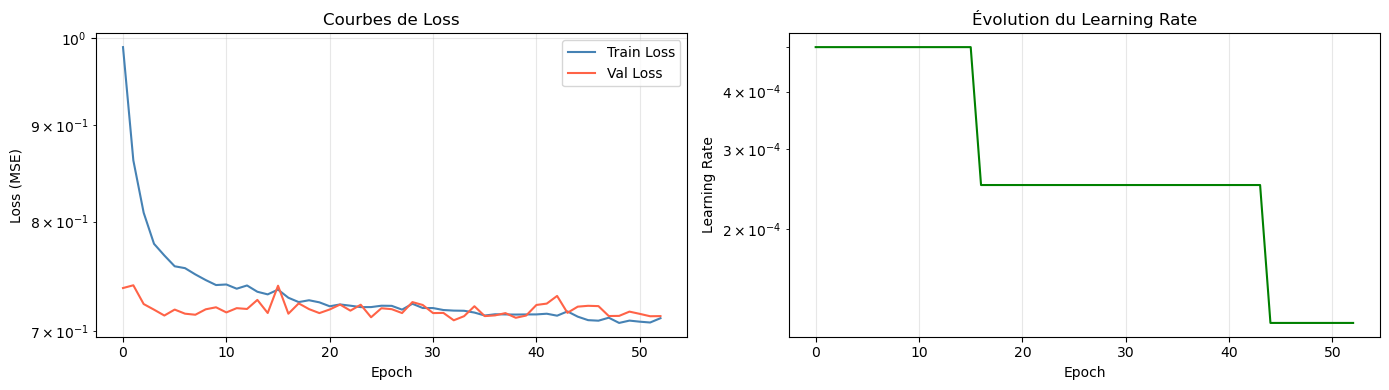

Courbes sauvegardées dans 'loss_curves.png'


In [27]:
# ============================================================
# CELL 22 : VISUALISATION DES COURBES DE LOSS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Train vs Val loss ---
ax = axes[0]
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
ax.plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel(f'Loss ({LOSS_MODE.upper()})')
ax.set_title('Courbes de Loss')
ax.legend()
ax.grid(alpha=0.3)
ax.set_yscale('log')

# --- Learning rate history ---
ax = axes[1]
ax.plot(lr_history, color='green', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Évolution du Learning Rate')
ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Courbes sauvegardées dans 'loss_curves.png'")


## Partie L — Évaluation

### Cellule 23 — Chargement du meilleur modèle et prédictions

In [28]:
# ============================================================
# CELL 23 : CHARGEMENT DU MEILLEUR MODÈLE ET PRÉDICTIONS TEST
# On inverse la normalisation pour obtenir des valeurs réelles.
# ============================================================

# Rechargement du meilleur checkpoint
checkpoint = torch.load('best_model.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Meilleur modèle chargé (epoch={checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.5f})")

# --- Prédictions sur le test ---
model.eval()
preds_norm_list = []
trues_norm_list = []

with torch.no_grad():
    for X_b, EA_b, Y_b in test_loader:
        X_b  = X_b.to(DEVICE)
        EA_b = EA_b.to(DEVICE)
        
        pred = model(X_b, EA_b, edge_index_dev)  # (B, HORIZON, N_WELLS)
        preds_norm_list.append(pred.cpu().numpy())
        trues_norm_list.append(Y_b.numpy())

preds_norm = np.concatenate(preds_norm_list, axis=0)  # (N_test, HORIZON, N_WELLS)
trues_norm = np.concatenate(trues_norm_list, axis=0)  # (N_test, HORIZON, N_WELLS)

print(f"preds_norm shape : {preds_norm.shape}")
print(f"trues_norm shape : {trues_norm.shape}")

# --- Inverse normalisation ---
# y_scaler a été fitté sur (T, N_WELLS) = 2D
# On reshape en (N*H, N_WELLS) pour inverse_transform

N_test, H, W = preds_norm.shape

def inverse_norm_predictions(arr, scaler):
    """Inverse la normalisation sur un array (N, H, N_WELLS)."""
    N, H_, W_ = arr.shape
    arr_2d = arr.reshape(N * H_, W_)
    arr_inv = scaler.inverse_transform(arr_2d)
    return arr_inv.reshape(N, H_, W_)

preds_real = inverse_norm_predictions(preds_norm, y_scaler)  # (N_test, HORIZON, N_WELLS)
trues_real = inverse_norm_predictions(trues_norm, y_scaler)  # (N_test, HORIZON, N_WELLS)

# Si TARGET_MODE == 'delta', on rajoute la dernière valeur observée
if TARGET_MODE == 'delta':
    # g_last_test[k] = dernière valeur g normalisée -> dénormalisée
    g_last_test_norm = g_norm[starts[idx_test] + HIST_HOURS - 1]  # (N_test, N_WELLS)
    g_last_test_real = y_scaler.inverse_transform(g_last_test_norm)  # (N_test, N_WELLS)
    preds_real = preds_real + g_last_test_real[:, np.newaxis, :]
    trues_real = trues_real + g_last_test_real[:, np.newaxis, :]
    print("Reconstruction des valeurs absolues depuis les deltas effectuée.")

print(f"\npreds_real shape : {preds_real.shape}")
print(f"trues_real shape : {trues_real.shape}")
print(f"preds_real range : [{preds_real.min():.4f}, {preds_real.max():.4f}]")
print(f"trues_real range : [{trues_real.min():.4f}, {trues_real.max():.4f}]")


Meilleur modèle chargé (epoch=33, val_loss=0.70930)
preds_norm shape : (218, 24, 4)
trues_norm shape : (218, 24, 4)

preds_real shape : (218, 24, 4)
trues_real shape : (218, 24, 4)
preds_real range : [0.2258, 3.0275]
trues_real range : [-0.0000, 4.0000]


### Cellule 24 — Métriques d'évaluation

In [29]:
# ============================================================
# CELL 24 : MÉTRIQUES D'ÉVALUATION
# MAE, RMSE, NMAE — global, par well, par horizon
# + Baseline de persistance (repeat last observed value)
# ============================================================

def compute_metrics(preds, trues, name="Modèle"):
    """Calcule MAE, RMSE, NMAE global et par well.
    
    Parameters
    ----------
    preds, trues : np.ndarray (N, H, W)
    
    Returns
    -------
    dict avec les métriques
    """
    # Global
    mae_global  = np.abs(preds - trues).mean()
    rmse_global = np.sqrt(((preds - trues)**2).mean())
    nmae_global = mae_global / (np.abs(trues).mean() + 1e-8)
    
    # Par well
    mae_per_well  = np.abs(preds - trues).mean(axis=(0, 1))   # (N_WELLS,)
    rmse_per_well = np.sqrt(((preds - trues)**2).mean(axis=(0, 1)))
    nmae_per_well = mae_per_well / (np.abs(trues).mean(axis=(0, 1)) + 1e-8)
    
    # Par horizon
    mae_per_h   = np.abs(preds - trues).mean(axis=(0, 2))    # (H,)
    rmse_per_h  = np.sqrt(((preds - trues)**2).mean(axis=(0, 2)))
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE  global  : {mae_global:.5f} MNm3")
    print(f"  RMSE global  : {rmse_global:.5f} MNm3")
    print(f"  NMAE global  : {nmae_global:.4f} ({nmae_global*100:.2f}%)")
    print(f"\n  Par well :")
    for j in range(preds.shape[-1]):
        print(f"    Well {j} (noeud {WELL_IDX[j]}) : "
              f"MAE={mae_per_well[j]:.5f} | RMSE={rmse_per_well[j]:.5f} | NMAE={nmae_per_well[j]:.4f}")
    
    return {
        'mae': mae_global, 'rmse': rmse_global, 'nmae': nmae_global,
        'mae_per_well': mae_per_well, 'rmse_per_well': rmse_per_well,
        'mae_per_h': mae_per_h, 'rmse_per_h': rmse_per_h,
    }

# --- Baseline de persistance ---
# Pour chaque fenêtre test, la dernière valeur observée de g est répétée
# sur tout l'horizon (24h).
# g_last_real[k, j] = g_full[starts[idx_test[k]] + HIST_HOURS - 1, j] (valeur réelle)
last_obs_idx = starts[idx_test] + HIST_HOURS - 1  # (N_test,)
g_last_real = g_full[last_obs_idx]                 # (N_test, N_WELLS)

# Répétition sur l'horizon : (N_test, HORIZON, N_WELLS)
baseline_real = np.repeat(g_last_real[:, np.newaxis, :], HORIZON_HOURS, axis=1)

print(f"Baseline persistance : shape={baseline_real.shape}")

# Métriques
metrics_model    = compute_metrics(preds_real,   trues_real, name="Modèle GNN")
metrics_baseline = compute_metrics(baseline_real, trues_real, name="Baseline Persistance")

# Comparaison
print(f"\n{'='*50}")
print(f"  Comparaison GNN vs Baseline")
print(f"{'='*50}")
ratio_mae  = metrics_model['mae']  / metrics_baseline['mae']
ratio_rmse = metrics_model['rmse'] / metrics_baseline['rmse']
print(f"  MAE  GNN / Baseline : {ratio_mae:.4f}  ({'MIEUX' if ratio_mae < 1 else 'MOINS BIEN'})")
print(f"  RMSE GNN / Baseline : {ratio_rmse:.4f}  ({'MIEUX' if ratio_rmse < 1 else 'MOINS BIEN'})")


Baseline persistance : shape=(218, 24, 4)

  Modèle GNN
  MAE  global  : 0.32329 MNm3
  RMSE global  : 0.41051 MNm3
  NMAE global  : 0.2493 (24.93%)

  Par well :
    Well 0 (noeud 0) : MAE=0.40155 | RMSE=0.50300 | NMAE=0.1574
    Well 1 (noeud 4) : MAE=0.35713 | RMSE=0.46129 | NMAE=0.3853
    Well 2 (noeud 16) : MAE=0.29122 | RMSE=0.35546 | NMAE=0.1937
    Well 3 (noeud 17) : MAE=0.24326 | RMSE=0.28621 | NMAE=1.1772

  Baseline Persistance
  MAE  global  : 0.42585 MNm3
  RMSE global  : 0.59153 MNm3
  NMAE global  : 0.3284 (32.84%)

  Par well :
    Well 0 (noeud 0) : MAE=0.55718 | RMSE=0.73001 | NMAE=0.2184
    Well 1 (noeud 4) : MAE=0.49775 | RMSE=0.67853 | NMAE=0.5370
    Well 2 (noeud 16) : MAE=0.35265 | RMSE=0.44858 | NMAE=0.2346
    Well 3 (noeud 17) : MAE=0.29583 | RMSE=0.45288 | NMAE=1.4316

  Comparaison GNN vs Baseline
  MAE  GNN / Baseline : 0.7592  (MIEUX)
  RMSE GNN / Baseline : 0.6940  (MIEUX)


## Partie M — Diagnostics d'alignement temporel

### Cellule 25 — Vérification de l'alignement

In [30]:
# ============================================================
# CELL 25 : DIAGNOSTIC D'ALIGNEMENT TEMPOREL
#
# On vérifie que trues_real[k] correspond exactement
# à g_full[t_out_start : t_out_end] pour chaque fenêtre k.
# C'est une vérification critique : si l'alignement est faux,
# le modèle est entraîné sur de mauvaises cibles.
# ============================================================

print("=== DIAGNOSTIC D'ALIGNEMENT TEMPOREL ===")
print()

# Vérification sur les 5 premières fenêtres test
n_check = min(5, len(idx_test))
all_ok = True

for k in range(n_check):
    win_idx = idx_test[k]
    t0 = starts[win_idx]
    t_out_start = t0 + HIST_HOURS
    t_out_end   = t0 + BLOCK
    
    # Valeur réelle attendue depuis g_full (non normalisé)
    true_expected = g_full[t_out_start:t_out_end]  # (HORIZON, N_WELLS)
    true_from_loader = trues_real[k]                # (HORIZON, N_WELLS)
    
    max_diff = np.abs(true_expected - true_from_loader).max()
    ok = max_diff < 1e-4
    all_ok = all_ok and ok
    
    print(f"Fenêtre test k={k} (starts[{win_idx}]={t0}) :")
    print(f"  Entrée  [h{t0} ... h{t_out_start-1}]")
    print(f"  Cible   [h{t_out_start} ... h{t_out_end-1}]")
    print(f"  Max diff |true_g_full - true_from_loader| = {max_diff:.2e}  {'✓ OK' if ok else '✗ ERREUR!'}")

if all_ok:
    print("\n✓ Alignement temporel confirmé sur toutes les fenêtres vérifiées")
else:
    print("\n✗ PROBLÈME D'ALIGNEMENT DÉTECTÉ — vérifier le pipeline de données !")

# Vérification du chevauchement entre fenêtres test consécutives
print("\n--- Chevauchement entre fenêtres test consécutives ---")
if len(idx_test) >= 2:
    t0_k0  = starts[idx_test[0]]
    t0_k1  = starts[idx_test[1]]
    gap    = t0_k1 - t0_k0
    overlap_in  = max(0, HIST_HOURS - gap)
    overlap_out = max(0, BLOCK - gap)
    print(f"  Stride entre fenêtres test : {gap}h")
    print(f"  Chevauchement en entrée    : {overlap_in}h / {HIST_HOURS}h")
    print(f"  Chevauchement en cible     : {overlap_out}h / {HORIZON_HOURS}h")
    if overlap_out > 0:
        print(f"  ATTENTION : deux fenêtres test consécutives partagent {overlap_out}h de cible !")
        print(f"  Ce n'est PAS deux jours indépendants — tenir compte dans l'interprétation.")


=== DIAGNOSTIC D'ALIGNEMENT TEMPOREL ===

Fenêtre test k=0 (starts[1231]=7386) :
  Entrée  [h7386 ... h7457]
  Cible   [h7458 ... h7481]
  Max diff |true_g_full - true_from_loader| = 1.38e-07  ✓ OK
Fenêtre test k=1 (starts[1232]=7392) :
  Entrée  [h7392 ... h7463]
  Cible   [h7464 ... h7487]
  Max diff |true_g_full - true_from_loader| = 1.20e-07  ✓ OK
Fenêtre test k=2 (starts[1233]=7398) :
  Entrée  [h7398 ... h7469]
  Cible   [h7470 ... h7493]
  Max diff |true_g_full - true_from_loader| = 1.20e-07  ✓ OK
Fenêtre test k=3 (starts[1234]=7404) :
  Entrée  [h7404 ... h7475]
  Cible   [h7476 ... h7499]
  Max diff |true_g_full - true_from_loader| = 1.22e-07  ✓ OK
Fenêtre test k=4 (starts[1235]=7410) :
  Entrée  [h7410 ... h7481]
  Cible   [h7482 ... h7505]
  Max diff |true_g_full - true_from_loader| = 1.22e-07  ✓ OK

✓ Alignement temporel confirmé sur toutes les fenêtres vérifiées

--- Chevauchement entre fenêtres test consécutives ---
  Stride entre fenêtres test : 6h
  Chevauchement en ent

### Cellule 26 — Diagnostic global : trues vs g_full

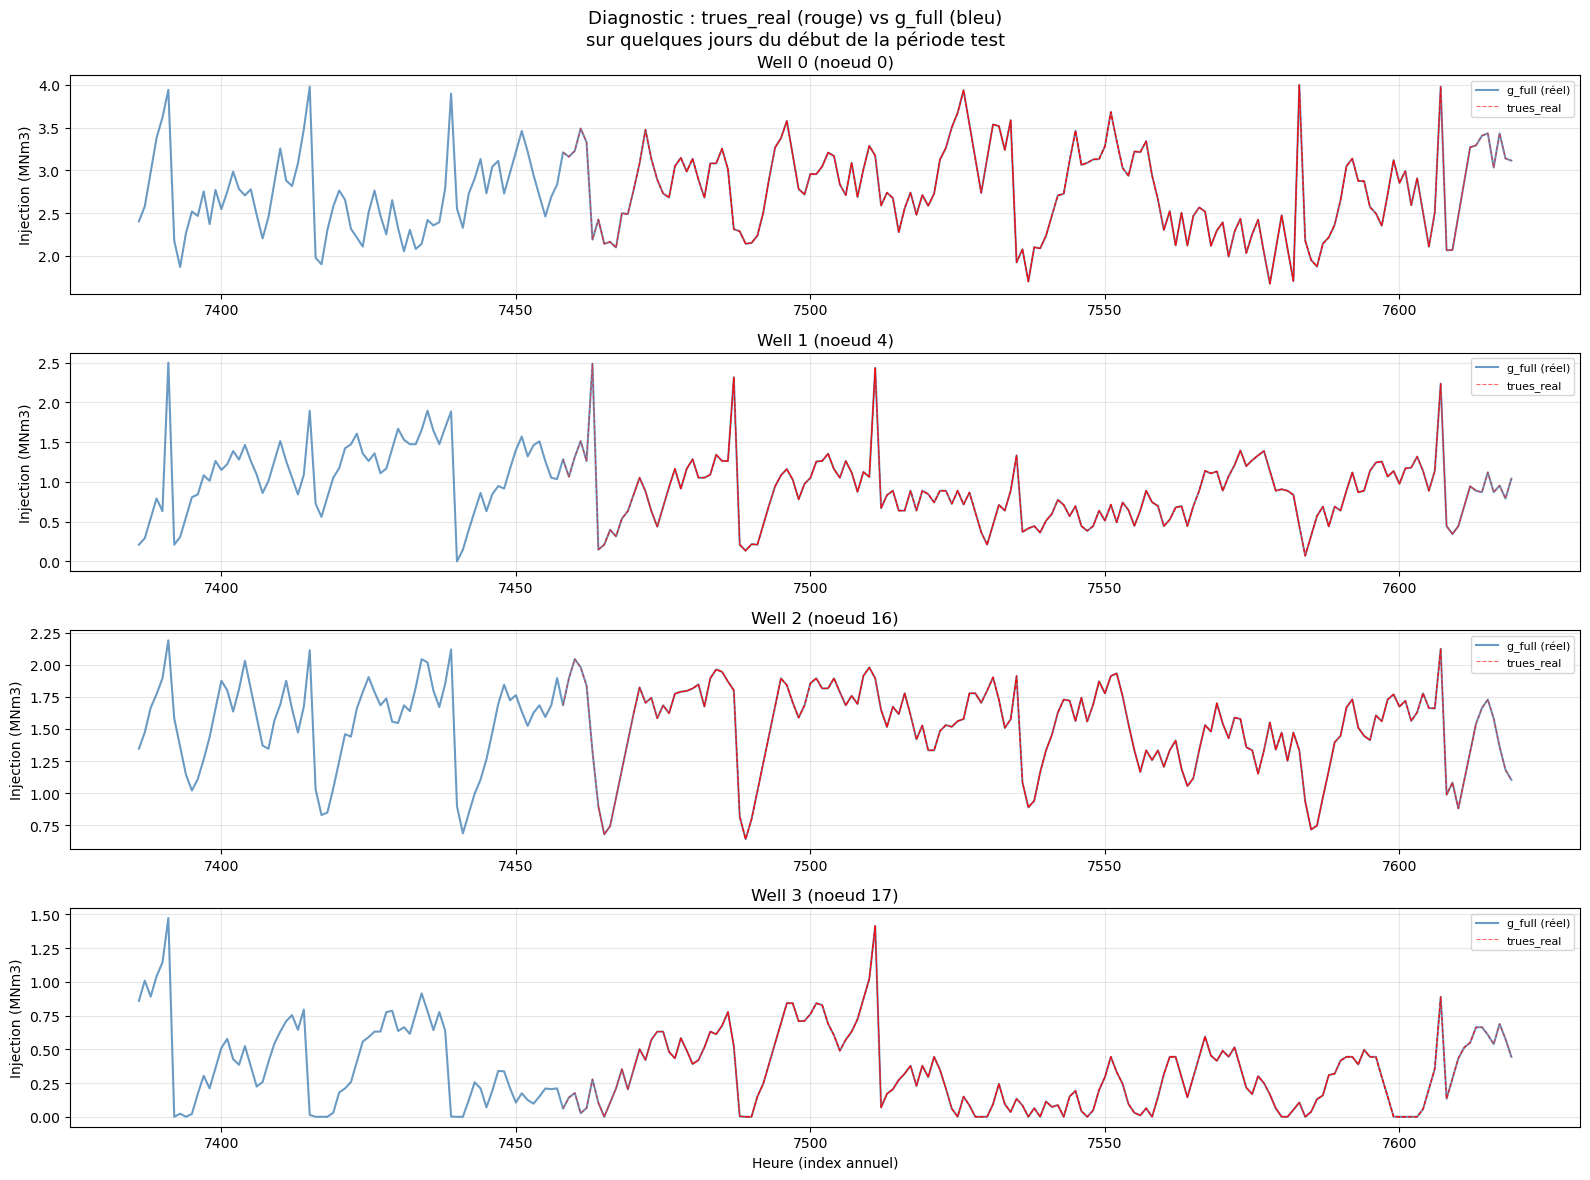

Alignement sauvegardé dans 'alignment_check.png'
Si bleu et rouge se superposent parfaitement -> alignement correct.


In [31]:
# ============================================================
# CELL 26 : VÉRIFICATION GLOBALE trues_real vs g_full
# On reconstruit la série continue des vraies cibles test
# et on la compare à g_full pour détecter tout décalage.
# ============================================================

fig, axes = plt.subplots(N_WELLS, 1, figsize=(16, 3*N_WELLS), sharex=False)
fig.suptitle("Diagnostic : trues_real (rouge) vs g_full (bleu)\n"
             "sur quelques jours du début de la période test", fontsize=13)

# Plage temporelle à afficher
k_start = 0
k_end   = min(24, len(idx_test))  # 24 premières fenêtres test
well_labels = [f"Well {j} (noeud {WELL_IDX[j]})" for j in range(N_WELLS)]

for j in range(N_WELLS):
    ax = axes[j]
    
    # Série brute g_full sur la période test correspondante
    t0_first = starts[idx_test[0]]
    t_last   = starts[idx_test[k_end-1]] + BLOCK
    g_segment = g_full[t0_first:t_last, j]
    t_range   = np.arange(t0_first, t_last)
    ax.plot(t_range, g_segment, color='steelblue', linewidth=1.5,
            label='g_full (réel)', alpha=0.8)
    
    # Cibles des fenêtres test sélectionnées
    for k in range(k_start, k_end):
        t0 = starts[idx_test[k]] + HIST_HOURS
        t_out = np.arange(t0, t0 + HORIZON_HOURS)
        ax.plot(t_out, trues_real[k, :, j], 'r--', linewidth=0.8,
                label='trues_real' if k == k_start else "", alpha=0.6)
    
    ax.set_title(well_labels[j])
    ax.set_ylabel('Injection (MNm3)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.xlabel('Heure (index annuel)')
plt.tight_layout()
plt.savefig('alignment_check.png', dpi=100, bbox_inches='tight')
plt.show()
print("Alignement sauvegardé dans 'alignment_check.png'")
print("Si bleu et rouge se superposent parfaitement -> alignement correct.")


## Partie N — Visualisations

### Cellule 27 — Prédictions sur une fenêtre test unique

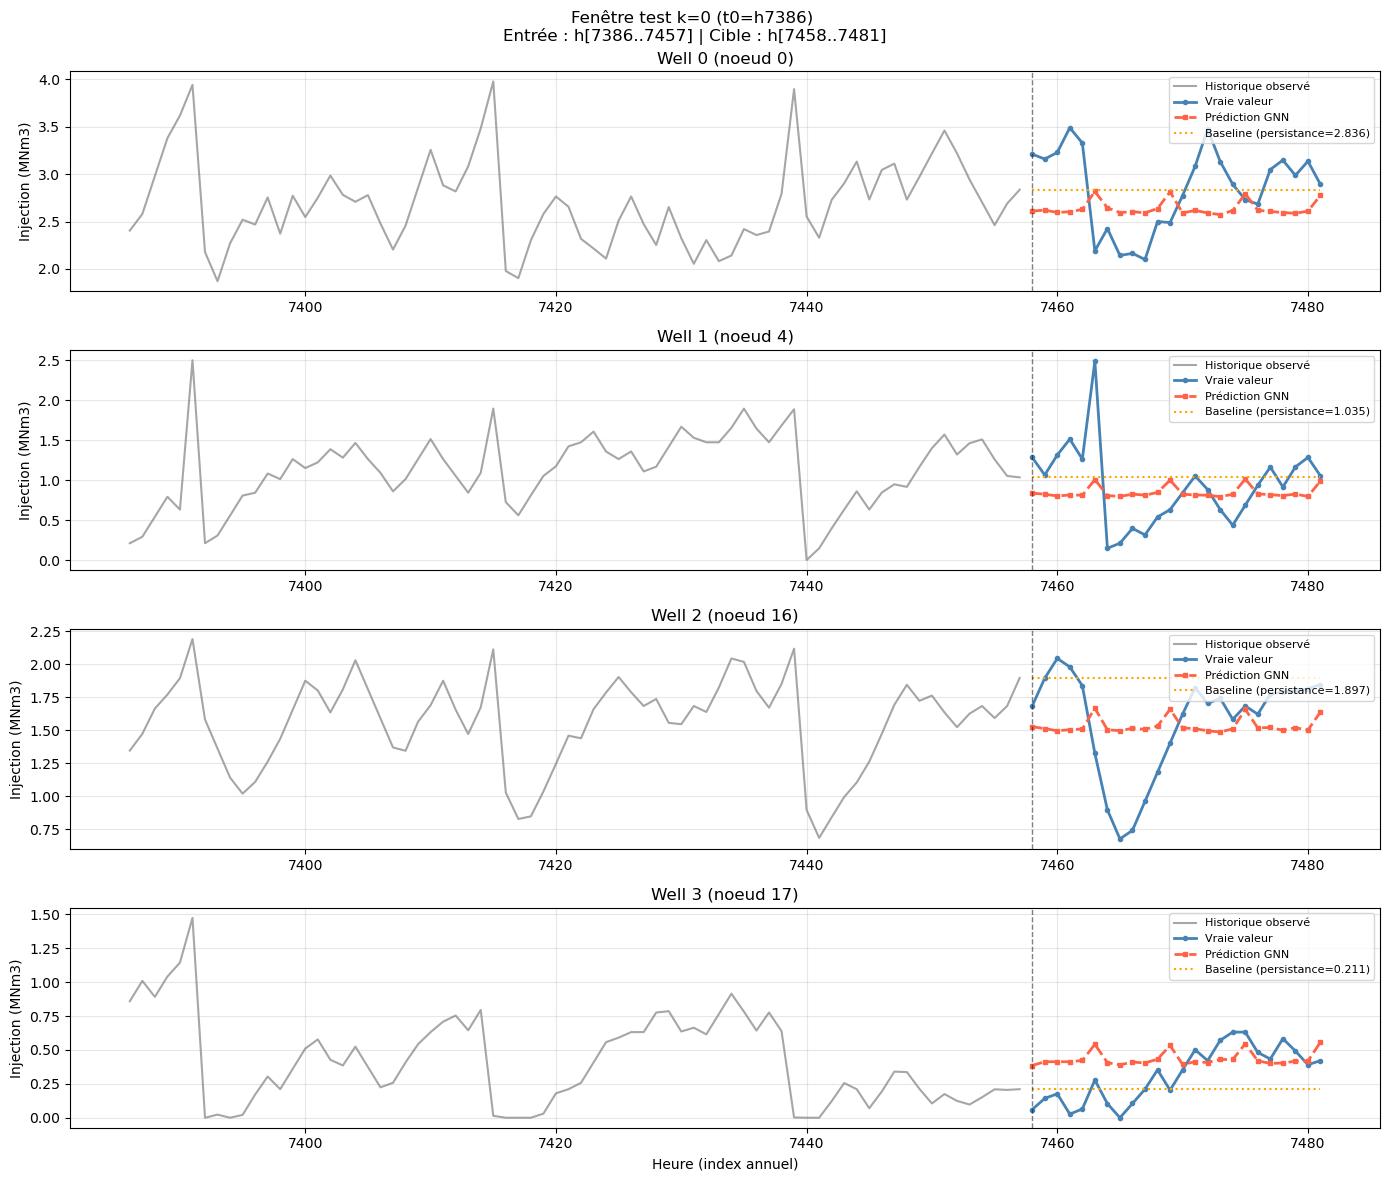

Plot sauvegardé dans 'single_window_pred.png'


In [32]:
# ============================================================
# CELL 27 : PLOT D'UNE FENÊTRE TEST UNIQUE
# Affiche pour chaque well :
#   - Historique observé (72h)
#   - Vraie valeur future (24h)
#   - Prédiction du modèle (24h)
#   - Baseline persistance
# ============================================================

def plot_single_window(k, preds_real, trues_real, g_full, starts, idx_test,
                       hist_hours=72, horizon=24, well_idx=WELL_IDX, title_suffix=""):
    """Plot d'une fenêtre test."""
    win_idx = idx_test[k]
    t0 = starts[win_idx]
    t_hist_range = np.arange(t0, t0 + hist_hours)
    t_pred_range = np.arange(t0 + hist_hours, t0 + hist_hours + horizon)
    
    fig, axes = plt.subplots(N_WELLS, 1, figsize=(14, 3*N_WELLS))
    fig.suptitle(f"Fenêtre test k={k} (t0=h{t0}) {title_suffix}\n"
                 f"Entrée : h[{t0}..{t0+hist_hours-1}] | Cible : h[{t0+hist_hours}..{t0+hist_hours+horizon-1}]",
                 fontsize=12)
    
    for j in range(N_WELLS):
        ax = axes[j]
        
        # Historique
        hist_vals = g_full[t_hist_range, j]
        ax.plot(t_hist_range, hist_vals, color='gray', linewidth=1.5,
                label='Historique observé', alpha=0.7)
        
        # Vraie future
        ax.plot(t_pred_range, trues_real[k, :, j], color='steelblue',
                linewidth=2, label='Vraie valeur', marker='o', markersize=3)
        
        # Prédiction GNN
        ax.plot(t_pred_range, preds_real[k, :, j], color='tomato',
                linewidth=2, label='Prédiction GNN', marker='s', markersize=3, linestyle='--')
        
        # Baseline persistance
        last_val = g_full[t0 + hist_hours - 1, j]
        ax.hlines(last_val, t_pred_range[0], t_pred_range[-1],
                  colors='orange', linestyles=':', linewidth=1.5,
                  label=f'Baseline (persistance={last_val:.3f})')
        
        # Séparateur historique / prédiction
        ax.axvline(t0 + hist_hours, color='black', linewidth=1, linestyle='--', alpha=0.5)
        
        ax.set_title(f"Well {j} (noeud {well_idx[j]})")
        ax.set_ylabel('Injection (MNm3)')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
    
    axes[-1].set_xlabel('Heure (index annuel)')
    plt.tight_layout()
    return fig


# Affichage pour k=0 (première fenêtre test)
fig = plot_single_window(0, preds_real, trues_real, g_full, starts, idx_test)
plt.savefig('single_window_pred.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot sauvegardé dans 'single_window_pred.png'")


### Cellule 28 — Métriques par horizon

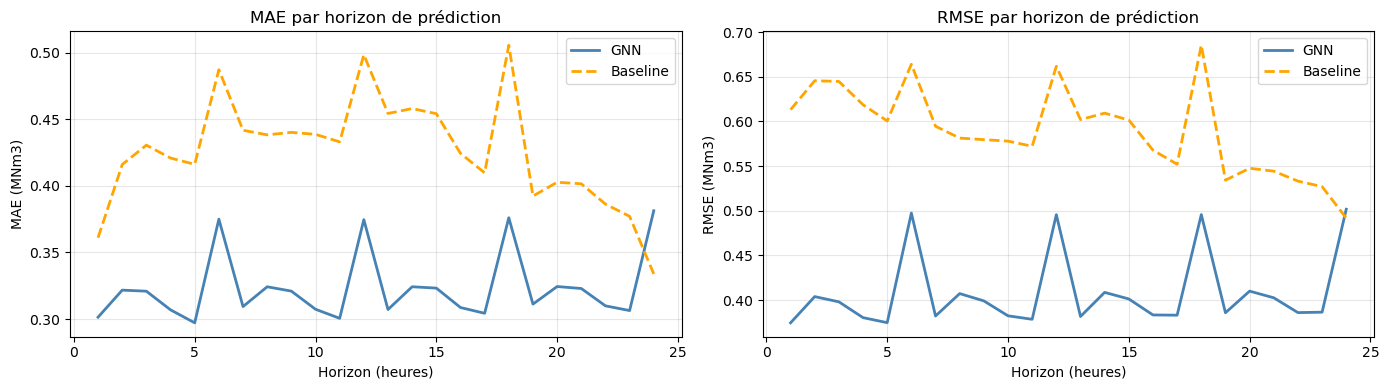

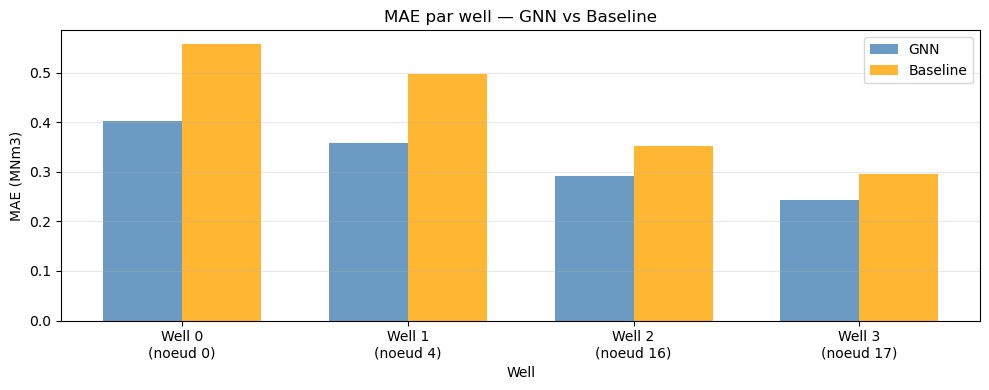

In [33]:
# ============================================================
# CELL 28 : MÉTRIQUES PAR HORIZON ET PAR WELL
# Permet de voir si le modèle se dégrade sur les horizons longs.
# ============================================================

mae_h_model    = metrics_model['mae_per_h']     # (HORIZON,)
rmse_h_model   = metrics_model['rmse_per_h']
mae_h_baseline = metrics_baseline['mae_per_h']
rmse_h_baseline= metrics_baseline['rmse_per_h']

horizons = np.arange(1, HORIZON_HOURS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(horizons, mae_h_model,    label='GNN',      color='steelblue', linewidth=2)
ax.plot(horizons, mae_h_baseline, label='Baseline', color='orange',    linewidth=2, linestyle='--')
ax.set_xlabel('Horizon (heures)')
ax.set_ylabel('MAE (MNm3)')
ax.set_title('MAE par horizon de prédiction')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(horizons, rmse_h_model,    label='GNN',      color='steelblue', linewidth=2)
ax.plot(horizons, rmse_h_baseline, label='Baseline', color='orange',    linewidth=2, linestyle='--')
ax.set_xlabel('Horizon (heures)')
ax.set_ylabel('RMSE (MNm3)')
ax.set_title('RMSE par horizon de prédiction')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_by_horizon.png', dpi=100, bbox_inches='tight')
plt.show()

# Métriques par well
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_WELLS)
width = 0.35
bars1 = ax.bar(x - width/2, metrics_model['mae_per_well'],    width, label='GNN',      color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, metrics_baseline['mae_per_well'], width, label='Baseline', color='orange',    alpha=0.8)
ax.set_xlabel('Well')
ax.set_ylabel('MAE (MNm3)')
ax.set_title('MAE par well — GNN vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels([f"Well {j}\n(noeud {WELL_IDX[j]})" for j in range(N_WELLS)])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('mae_per_well.png', dpi=100, bbox_inches='tight')
plt.show()


### Cellule 29 — Séries brutes des wells sur l'année

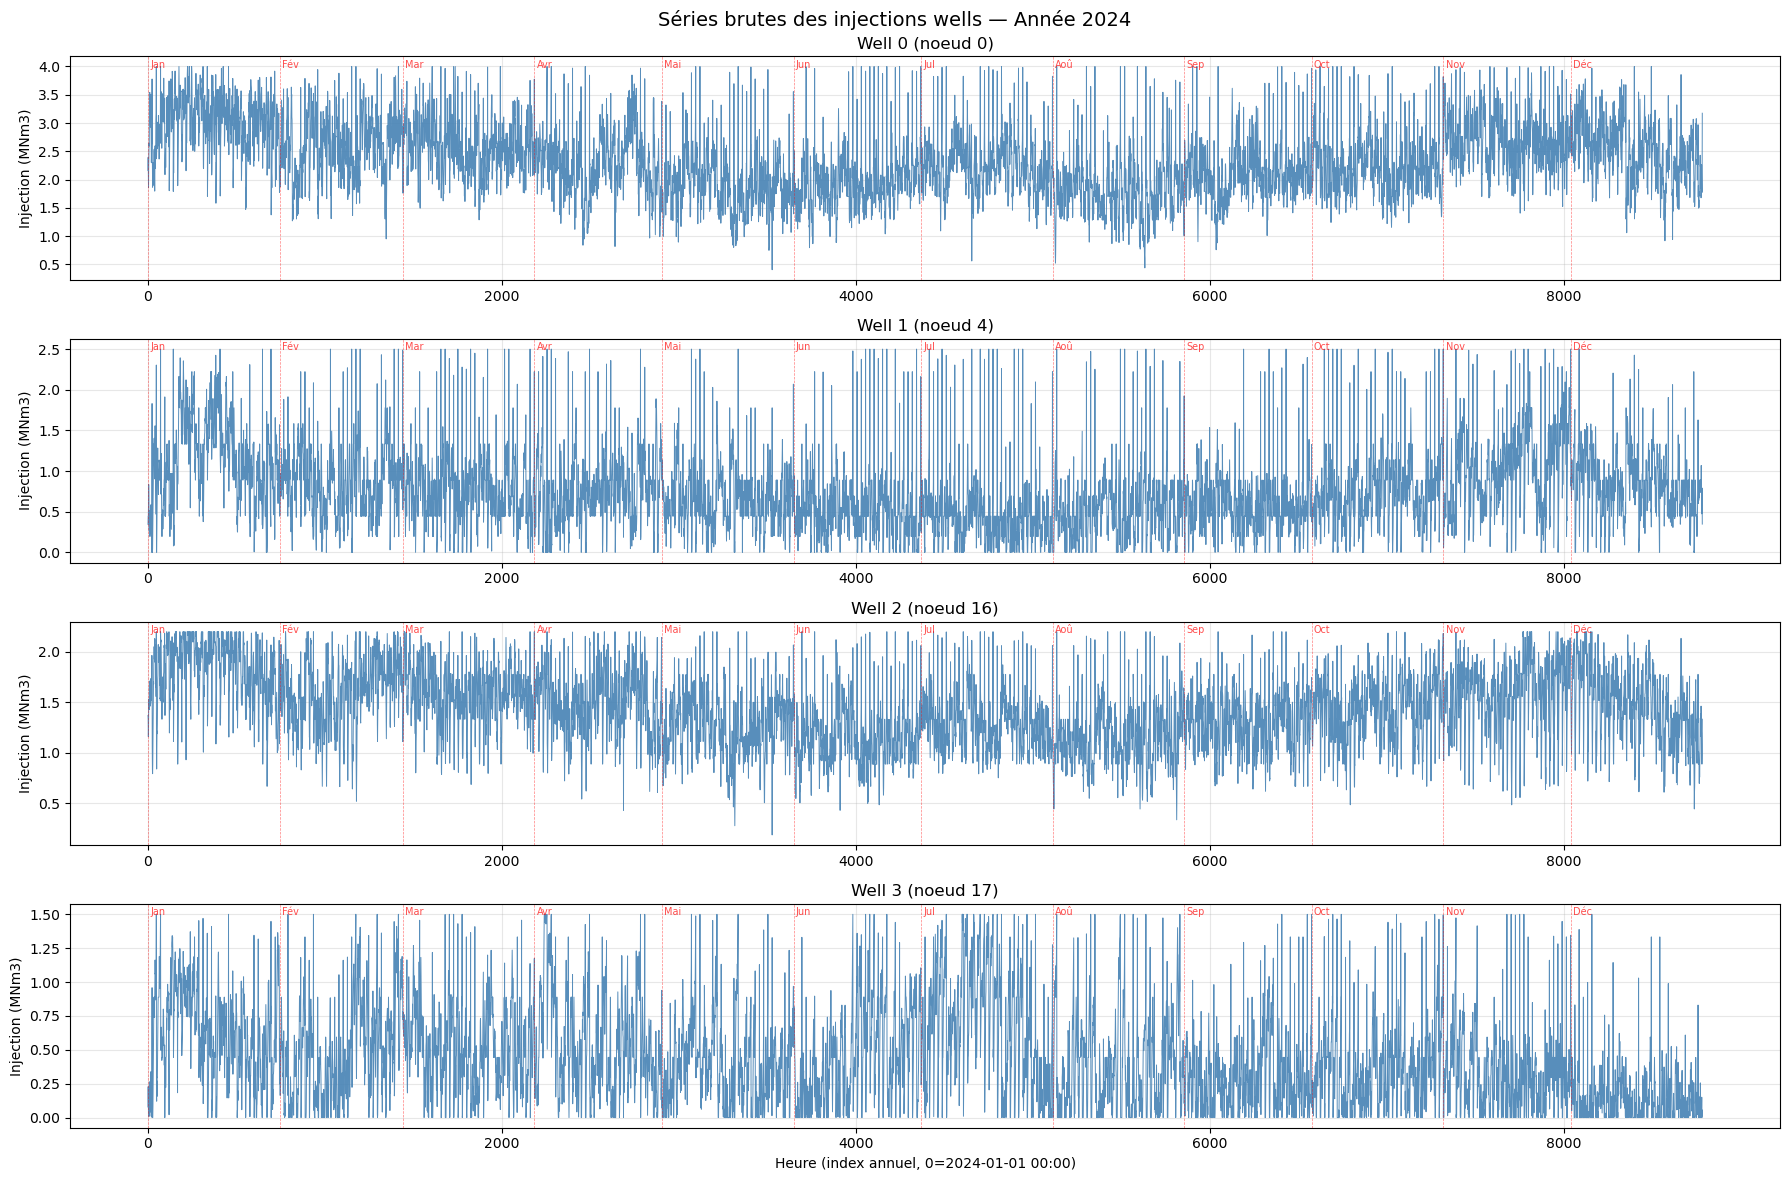

Sauvegardé dans 'raw_series_wells.png'
Vérifier qu'il n'y a pas de saut artificiel aux frontières mensuelles.


In [34]:
# ============================================================
# CELL 29 : SÉRIES BRUTES DES 4 WELLS SUR L'ANNÉE
# Visualisation de l'ensemble du signal de référence.
# Ajout des frontières mensuelles pour détecter d'éventuelles
# discontinuités suspectes dans les données.
# ============================================================

# Calcul des indices de début de chaque mois (approximatif)
import calendar
month_start_hours = [0]
for m in range(1, 12):
    days_in_month = calendar.monthrange(2024, m)[1]
    month_start_hours.append(month_start_hours[-1] + 24 * days_in_month)

month_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
               'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axes = plt.subplots(N_WELLS, 1, figsize=(18, 3*N_WELLS))
fig.suptitle("Séries brutes des injections wells — Année 2024", fontsize=14)

t_all = np.arange(T)
for j in range(N_WELLS):
    ax = axes[j]
    ax.plot(t_all, g_full[:, j], color='steelblue', linewidth=0.7, alpha=0.9)
    
    # Séparateurs mensuels
    for i, t_m in enumerate(month_start_hours):
        ax.axvline(t_m, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
        if t_m < T:
            ax.text(t_m + 12, ax.get_ylim()[1] * 0.95, month_names[i],
                   fontsize=7, color='red', alpha=0.7)
    
    ax.set_title(f"Well {j} (noeud {WELL_IDX[j]})")
    ax.set_ylabel('Injection (MNm3)')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Heure (index annuel, 0=2024-01-01 00:00)')
plt.tight_layout()
plt.savefig('raw_series_wells.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sauvegardé dans 'raw_series_wells.png'")
print("Vérifier qu'il n'y a pas de saut artificiel aux frontières mensuelles.")


## Partie O — Diagnostics de structure du modèle

### Cellule 30 — Variance et corrélation

=== DIAGNOSTICS DE STRUCTURE DU MODÈLE ===

Variance des prédictions vs réalité par well :
  Well 0 : Var(true)=0.26367 | Var(pred)=0.05320 | ratio=0.202  ⚠ SOUS-ESTIME LA VARIANCE
  Well 1 : Var(true)=0.20776 | Var(pred)=0.01161 | ratio=0.056  ⚠ SOUS-ESTIME LA VARIANCE
  Well 2 : Var(true)=0.13836 | Var(pred)=0.01215 | ratio=0.088  ⚠ SOUS-ESTIME LA VARIANCE
  Well 3 : Var(true)=0.05692 | Var(pred)=0.00476 | ratio=0.084  ⚠ SOUS-ESTIME LA VARIANCE

Corrélation Pearson entre vraies et prédites :
  Well 0 : r = 0.2753
  Well 1 : r = 0.1972
  Well 2 : r = 0.2950
  Well 3 : r = 0.2266


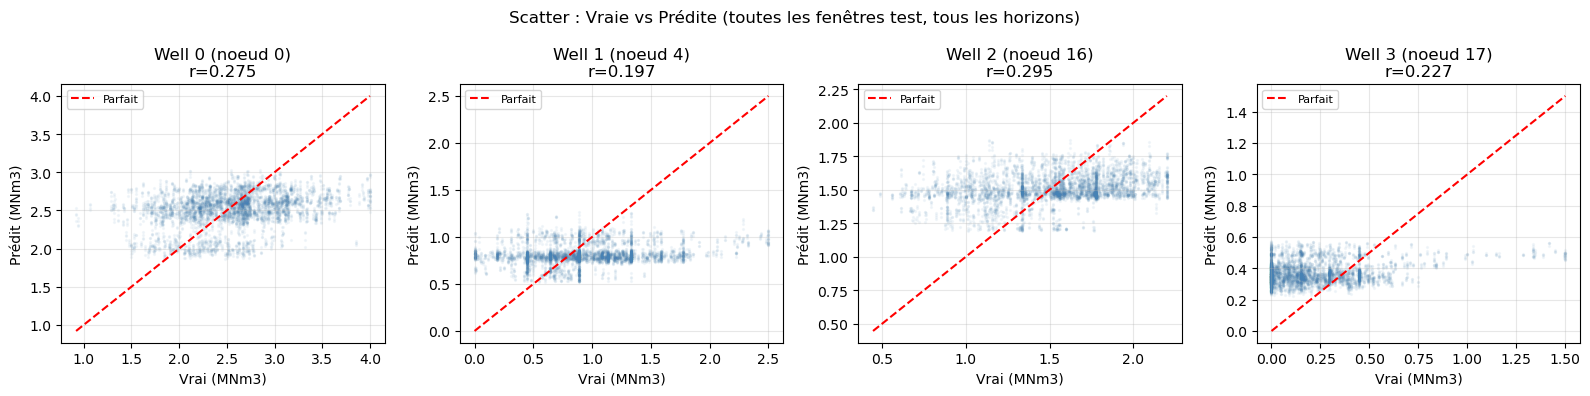

In [35]:
# ============================================================
# CELL 30 : DIAGNOSTICS — VARIANCE ET CORRÉLATION
# Un modèle qui lisse trop aura une variance de prédiction
# beaucoup plus faible que la variance du vrai signal.
# ============================================================

print("=== DIAGNOSTICS DE STRUCTURE DU MODÈLE ===")
print()

# --- Variance des prédictions vs vraies ---
print("Variance des prédictions vs réalité par well :")
for j in range(N_WELLS):
    var_true = trues_real[:, :, j].var()
    var_pred = preds_real[:, :, j].var()
    ratio = var_pred / var_true
    flag = "⚠ SOUS-ESTIME LA VARIANCE" if ratio < 0.5 else "✓" if ratio > 0.8 else "~OK"
    print(f"  Well {j} : Var(true)={var_true:.5f} | Var(pred)={var_pred:.5f} | "
          f"ratio={ratio:.3f}  {flag}")

# --- Corrélation Pearson par well ---
print("\nCorrélation Pearson entre vraies et prédites :")
for j in range(N_WELLS):
    t_flat  = trues_real[:, :, j].flatten()
    p_flat  = preds_real[:, :, j].flatten()
    corr = np.corrcoef(t_flat, p_flat)[0, 1]
    print(f"  Well {j} : r = {corr:.4f}")

# --- Scatter plot True vs Pred ---
fig, axes = plt.subplots(1, N_WELLS, figsize=(4*N_WELLS, 4))
fig.suptitle("Scatter : Vraie vs Prédite (toutes les fenêtres test, tous les horizons)", fontsize=12)

for j in range(N_WELLS):
    ax = axes[j]
    t_flat = trues_real[:, :, j].flatten()
    p_flat = preds_real[:, :, j].flatten()
    
    ax.scatter(t_flat, p_flat, alpha=0.05, s=2, color='steelblue')
    lims = [min(t_flat.min(), p_flat.min()), max(t_flat.max(), p_flat.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Parfait')
    
    corr = np.corrcoef(t_flat, p_flat)[0, 1]
    ax.set_title(f"Well {j} (noeud {WELL_IDX[j]})\nr={corr:.3f}")
    ax.set_xlabel('Vrai (MNm3)')
    ax.set_ylabel('Prédit (MNm3)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_true_pred.png', dpi=100, bbox_inches='tight')
plt.show()


### Cellule 31 — Résidus et lissage excessif

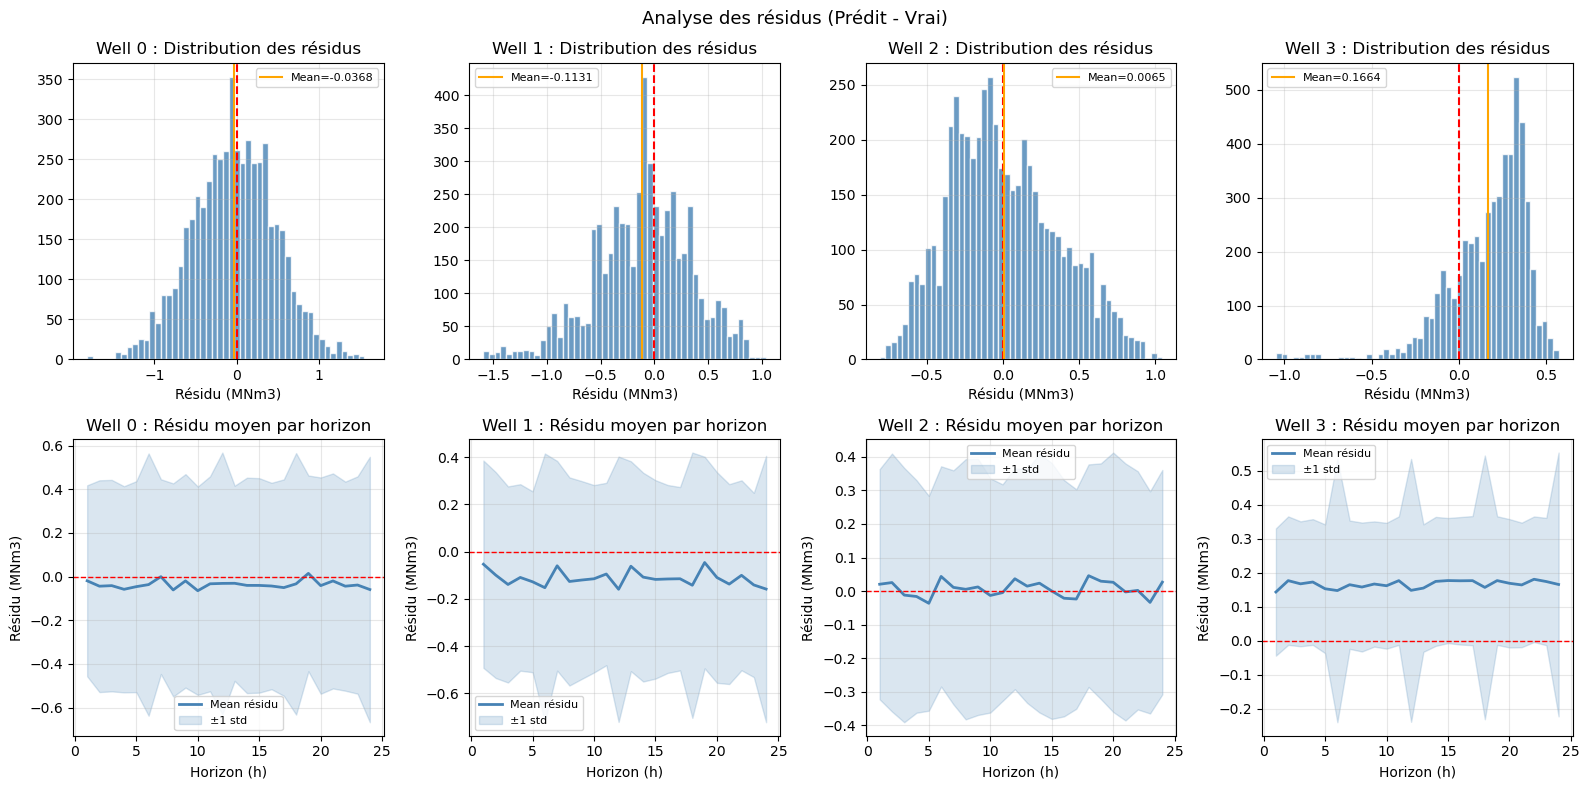


--- Détection de lissage excessif ---
  Well 0 : 204/218 fenêtres où amplitude prédite < 20% de l'amplitude vraie
  Well 1 : 162/218 fenêtres où amplitude prédite < 20% de l'amplitude vraie
  Well 2 : 186/218 fenêtres où amplitude prédite < 20% de l'amplitude vraie
  Well 3 : 87/218 fenêtres où amplitude prédite < 20% de l'amplitude vraie


In [36]:
# ============================================================
# CELL 31 : RÉSIDUS ET DÉTECTION DE LISSAGE EXCESSIF
# ============================================================

residuals = preds_real - trues_real  # (N_test, HORIZON, N_WELLS)

fig, axes = plt.subplots(2, N_WELLS, figsize=(4*N_WELLS, 8))
fig.suptitle("Analyse des résidus (Prédit - Vrai)", fontsize=13)

for j in range(N_WELLS):
    # Distribution des résidus
    ax = axes[0, j]
    res_flat = residuals[:, :, j].flatten()
    ax.hist(res_flat, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.axvline(res_flat.mean(), color='orange', linewidth=1.5, label=f"Mean={res_flat.mean():.4f}")
    ax.set_title(f"Well {j} : Distribution des résidus")
    ax.set_xlabel('Résidu (MNm3)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # Résidus par horizon
    ax = axes[1, j]
    res_per_h_mean = residuals[:, :, j].mean(axis=0)    # (HORIZON,)
    res_per_h_std  = residuals[:, :, j].std(axis=0)
    h_range = np.arange(1, HORIZON_HOURS+1)
    ax.plot(h_range, res_per_h_mean, color='steelblue', linewidth=2, label='Mean résidu')
    ax.fill_between(h_range,
                    res_per_h_mean - res_per_h_std,
                    res_per_h_mean + res_per_h_std,
                    alpha=0.2, color='steelblue', label='±1 std')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(f"Well {j} : Résidu moyen par horizon")
    ax.set_xlabel('Horizon (h)')
    ax.set_ylabel('Résidu (MNm3)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=100, bbox_inches='tight')
plt.show()

# Détection cas de lissage : trouver les fenêtres où l'amplitude
# de la prédiction est très faible par rapport à la vraie
print("\n--- Détection de lissage excessif ---")
for j in range(N_WELLS):
    amp_true = trues_real[:, :, j].max(axis=1) - trues_real[:, :, j].min(axis=1)  # (N_test,)
    amp_pred = preds_real[:, :, j].max(axis=1) - preds_real[:, :, j].min(axis=1)
    ratio_amp = amp_pred / (amp_true + 1e-8)
    n_flat = (ratio_amp < 0.2).sum()
    print(f"  Well {j} : {n_flat}/{len(idx_test)} fenêtres où amplitude prédite < 20% de l'amplitude vraie")


## Partie P — Expérimentations faciles

### Cellule 32 — Guide des variantes

In [37]:
# ============================================================
# CELL 32 : GUIDE DES VARIANTES ET EXPÉRIMENTATIONS
#
# Toutes les variantes se contrôlent depuis la Cellule 2.
# Ce guide résume comment passer d'une variante à l'autre.
# ============================================================

guide = """
GUIDE DES VARIANTES (modifier uniquement la Cellule 2 puis re-exécuter le notebook)
===================================================================================

1. FEATURES D'ARÊTE :
   EDGE_FEATURE_MODE = 'dynamic'  -> q seulement
   EDGE_FEATURE_MODE = 'static'   -> compressor factor + longueur
   EDGE_FEATURE_MODE = 'both'     -> q + compressor factor + longueur  [défaut]

2. DIRECTION DU DÉBIT :
   Q_DIRECTION_MODE = 'abs'       -> |q| pour les deux directions
   Q_DIRECTION_MODE = 'signed'    -> q forward, -q backward  [défaut]

3. FEATURES NODALES :
   USE_GLOBAL_CONS = True/False   -> activer/désactiver les consommations globales
   USE_G_NODE = True/False        -> activer/désactiver l'injection g sur les noeuds wells
   USE_SIN_COS_TIME = True/False  -> encodage sin/cos de l'heure et du jour

4. TARGETS :
   TARGET_MODE = 'absolute'       -> prédire les valeurs absolues  [défaut]
   TARGET_MODE = 'delta'          -> prédire les différences depuis la dernière heure

5. MODULE TEMPOREL :
   TEMPORAL_MODE = 'attention'    -> attention multi-têtes  [défaut]
   TEMPORAL_MODE = 'gru'          -> GRU par noeud

6. LOSS :
   LOSS_MODE = 'mse'              -> MSE classique  [défaut]
   LOSS_MODE = 'huber'            -> Huber loss (robuste aux outliers)
   HUBER_DELTA = 1.0              -> delta de la Huber loss

7. ARCHITECTURE :
   HIDDEN_DIM = 32/64/128         -> taille des couches cachées
   N_MP_LAYERS = 1/2/3            -> nombre de couches de message passing
   N_ATTN_HEADS = 2/4/8           -> têtes d'attention
   DROPOUT = 0.0/0.1/0.2          -> taux de dropout

8. ENTRAÎNEMENT :
   LR = 1e-3 / 5e-4 / 1e-4       -> learning rate
   WEIGHT_DECAY = 0 / 1e-3       -> régularisation L2
   PATIENCE = 10/20/30            -> patience early stopping
   BATCH_SIZE = 16/32/64          -> taille du batch
"""

print(guide)



GUIDE DES VARIANTES (modifier uniquement la Cellule 2 puis re-exécuter le notebook)

1. FEATURES D'ARÊTE :
   EDGE_FEATURE_MODE = 'dynamic'  -> q seulement
   EDGE_FEATURE_MODE = 'static'   -> compressor factor + longueur
   EDGE_FEATURE_MODE = 'both'     -> q + compressor factor + longueur  [défaut]

2. DIRECTION DU DÉBIT :
   Q_DIRECTION_MODE = 'abs'       -> |q| pour les deux directions
   Q_DIRECTION_MODE = 'signed'    -> q forward, -q backward  [défaut]

3. FEATURES NODALES :
   USE_GLOBAL_CONS = True/False   -> activer/désactiver les consommations globales
   USE_G_NODE = True/False        -> activer/désactiver l'injection g sur les noeuds wells
   USE_SIN_COS_TIME = True/False  -> encodage sin/cos de l'heure et du jour

4. TARGETS :
   TARGET_MODE = 'absolute'       -> prédire les valeurs absolues  [défaut]
   TARGET_MODE = 'delta'          -> prédire les différences depuis la dernière heure

5. MODULE TEMPOREL :
   TEMPORAL_MODE = 'attention'    -> attention multi-têtes  [défa

### Cellule 33 — Comparaison GNN vs Baseline (plot final)

Fenêtres sélectionnées (non-chevauchantes en cible) : [0, 4, 8]


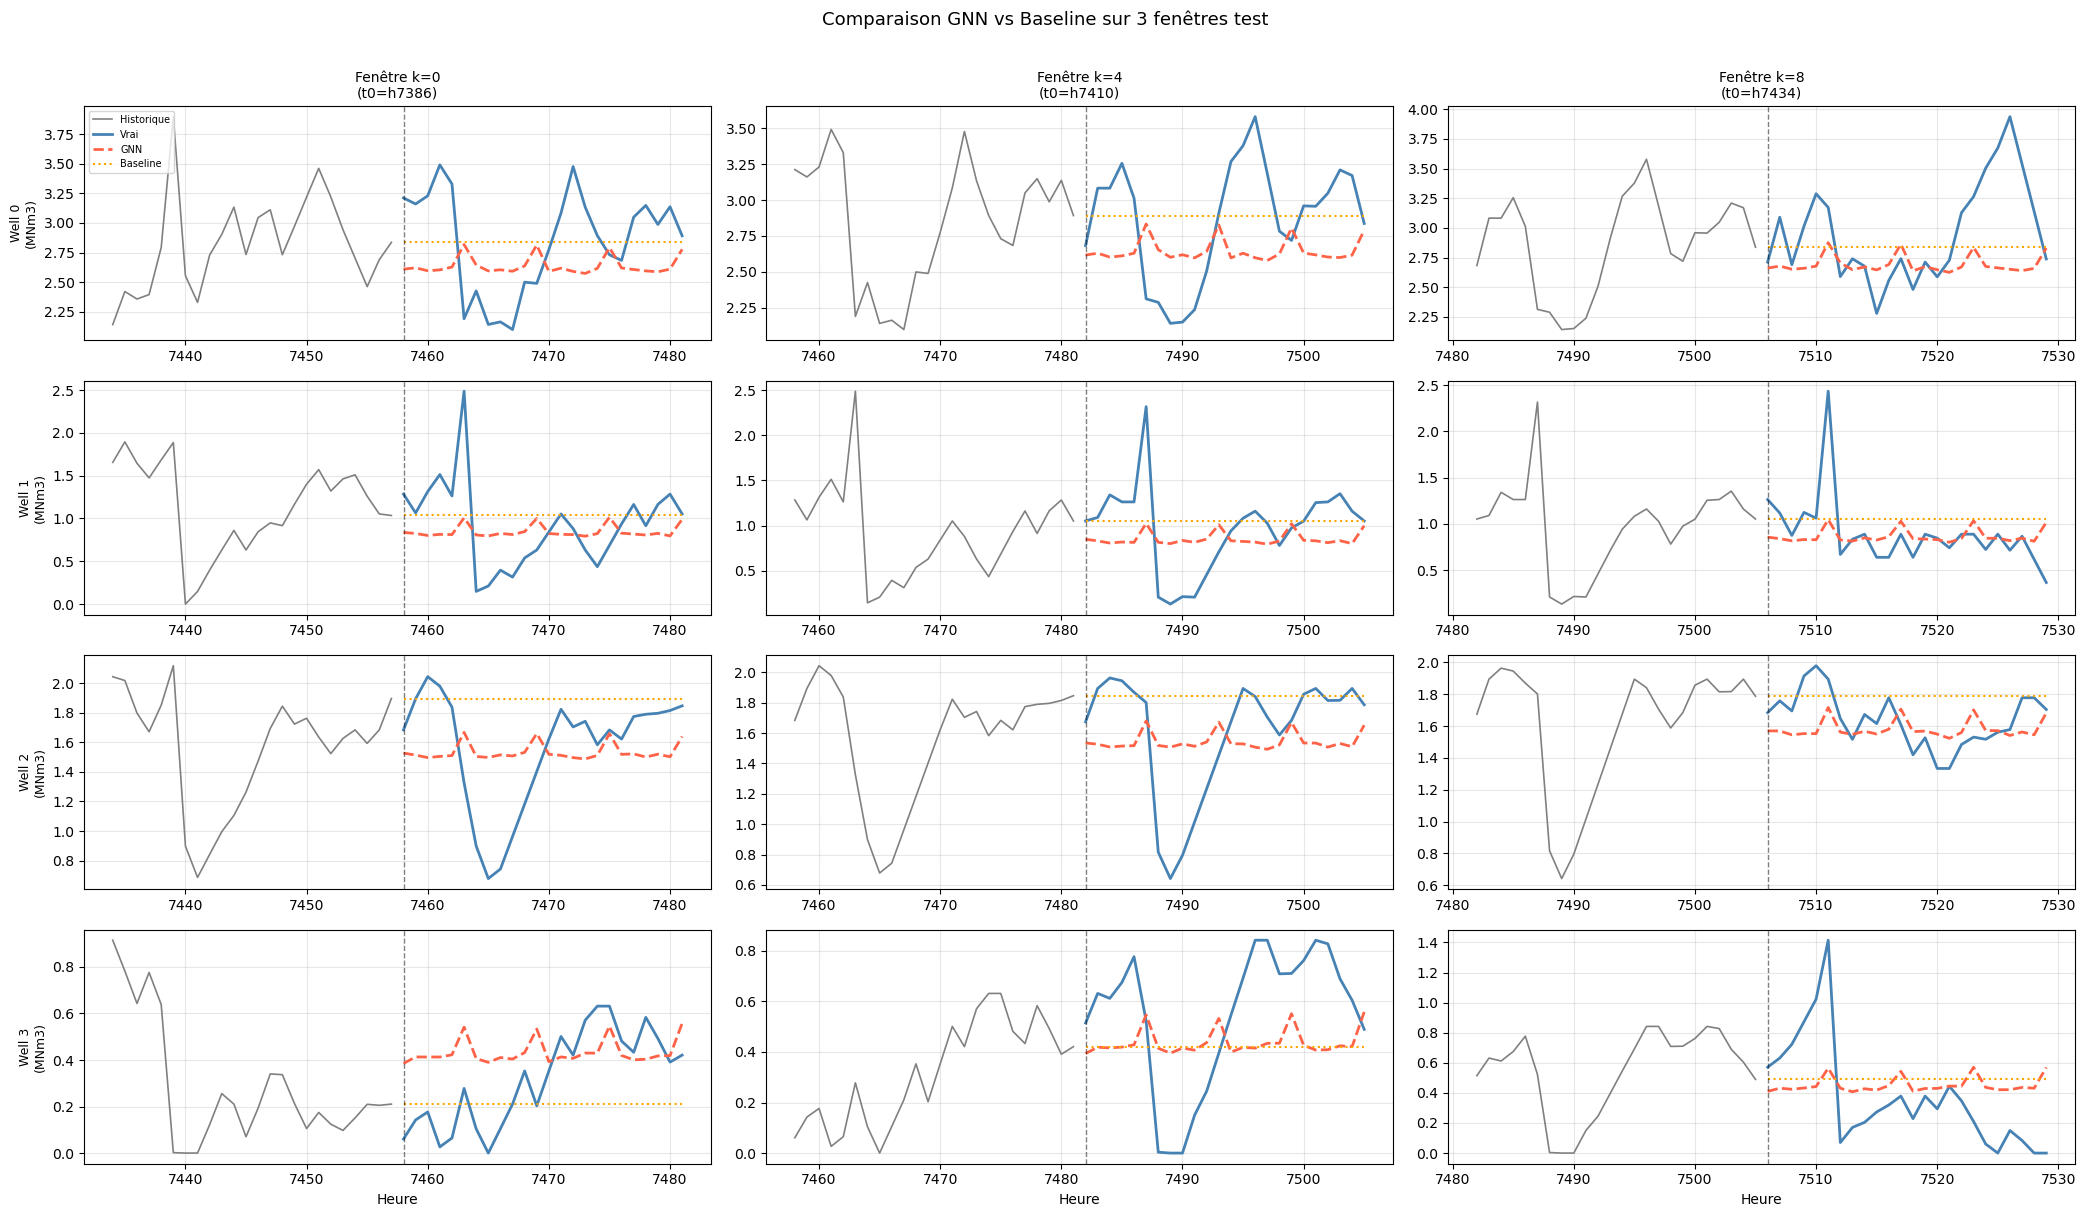

Sauvegardé dans 'gnn_vs_baseline.png'


In [38]:
# ============================================================
# CELL 33 : PLOT COMPARAISON GNN vs BASELINE
# Sur 3 fenêtres test non-chevauchantes (stride artificiel = HORIZON)
# ============================================================

# Sélection de 3 fenêtres test non-chevauchantes
# On prend des fenêtres séparées par au moins HORIZON_HOURS
non_overlap_stride = max(1, HORIZON_HOURS // STRIDE)
k_indices = list(range(0, min(len(idx_test), 3 * non_overlap_stride), non_overlap_stride))[:3]

print(f"Fenêtres sélectionnées (non-chevauchantes en cible) : {k_indices}")

fig, axes = plt.subplots(N_WELLS, len(k_indices), figsize=(7*len(k_indices), 3*N_WELLS))
if len(k_indices) == 1:
    axes = axes[:, np.newaxis]

for col, k in enumerate(k_indices):
    win_idx = idx_test[k]
    t0 = starts[win_idx]
    t_hist = np.arange(t0, t0 + HIST_HOURS)
    t_pred = np.arange(t0 + HIST_HOURS, t0 + BLOCK)
    
    for j in range(N_WELLS):
        ax = axes[j, col]
        
        # Historique (dernier tiers pour lisibilité)
        show_hist = HIST_HOURS // 3
        ax.plot(t_hist[-show_hist:], g_full[t_hist[-show_hist:], j],
                color='gray', linewidth=1.2, label='Historique')
        
        # Vraie future
        ax.plot(t_pred, trues_real[k, :, j], color='steelblue',
                linewidth=2, label='Vrai')
        
        # Prédiction GNN
        ax.plot(t_pred, preds_real[k, :, j], color='tomato',
                linewidth=2, linestyle='--', label='GNN')
        
        # Baseline
        last_val = g_full[t0 + HIST_HOURS - 1, j]
        ax.hlines(last_val, t_pred[0], t_pred[-1],
                  colors='orange', linestyles=':', linewidth=1.5, label='Baseline')
        
        ax.axvline(t0 + HIST_HOURS, color='black', linewidth=1,
                   linestyle='--', alpha=0.5)
        
        if col == 0:
            ax.set_ylabel(f'Well {j}\n(MNm3)', fontsize=9)
        if j == 0:
            ax.set_title(f"Fenêtre k={k}\n(t0=h{t0})", fontsize=10)
        if j == N_WELLS - 1:
            ax.set_xlabel('Heure')
        if j == 0 and col == 0:
            ax.legend(loc='upper left', fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle("Comparaison GNN vs Baseline sur 3 fenêtres test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('gnn_vs_baseline.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sauvegardé dans 'gnn_vs_baseline.png'")


### Cellule 34 — Résumé final

In [39]:
# ============================================================
# CELL 34 : RÉSUMÉ FINAL DU PIPELINE
# ============================================================

print("=" * 60)
print("   RÉSUMÉ DU PIPELINE GNN GAZ")
print("=" * 60)
print(f"  Données     : {T} heures (2024, bissextile)")
print(f"  Réseau      : {N_NODES} noeuds, {N_PIPES} pipelines, {E} arêtes")
print(f"  Wells       : {N_WELLS} (indices {WELL_IDX})")
print(f"  Fenêtres    : S={S} (stride={STRIDE}h)")
print(f"  Split       : train={n_train} | val={n_val} | test={n_test}")
print(f"  F_node={F_NODE}, F_edge={F_EDGE}")
print(f"  Modèle      : {TEMPORAL_MODE} | HD={HIDDEN_DIM} | MP={N_MP_LAYERS}")
print(f"  Paramètres  : {sum(p.numel() for p in model.parameters()):,}")
print()
print("  --- Métriques test (valeurs réelles, MNm3) ---")
print(f"  MAE  GNN      : {metrics_model['mae']:.5f}")
print(f"  RMSE GNN      : {metrics_model['rmse']:.5f}")
print(f"  NMAE GNN      : {metrics_model['nmae']:.4f} ({metrics_model['nmae']*100:.2f}%)")
print(f"  MAE  Baseline : {metrics_baseline['mae']:.5f}")
print(f"  NMAE Baseline : {metrics_baseline['nmae']:.4f} ({metrics_baseline['nmae']*100:.2f}%)")
ratio = metrics_model['mae'] / metrics_baseline['mae']
print(f"  Ratio GNN/Baseline : {ratio:.3f}  ({'✓ MIEUX' if ratio < 1 else '✗ À améliorer'})")
print()
print("  --- Fichiers générés ---")
import os
for f in ['best_model.pt','loss_curves.png','alignment_check.png',
          'single_window_pred.png','metrics_by_horizon.png',
          'mae_per_well.png','raw_series_wells.png','scatter_true_pred.png',
          'residuals.png','gnn_vs_baseline.png']:
    exists = "✓" if os.path.exists(f) else "✗"
    print(f"  {exists} {f}")


   RÉSUMÉ DU PIPELINE GNN GAZ
  Données     : 8784 heures (2024, bissextile)
  Réseau      : 28 noeuds, 33 pipelines, 66 arêtes
  Wells       : 4 (indices [0, 4, 16, 17])
  Fenêtres    : S=1449 (stride=6h)
  Split       : train=1014 | val=217 | test=218
  F_node=7, F_edge=3
  Modèle      : attention | HD=64 | MP=2
  Paramètres  : 69,464

  --- Métriques test (valeurs réelles, MNm3) ---
  MAE  GNN      : 0.32329
  RMSE GNN      : 0.41051
  NMAE GNN      : 0.2493 (24.93%)
  MAE  Baseline : 0.42585
  NMAE Baseline : 0.3284 (32.84%)
  Ratio GNN/Baseline : 0.759  (✓ MIEUX)

  --- Fichiers générés ---
  ✓ best_model.pt
  ✓ loss_curves.png
  ✓ alignment_check.png
  ✓ single_window_pred.png
  ✓ metrics_by_horizon.png
  ✓ mae_per_well.png
  ✓ raw_series_wells.png
  ✓ scatter_true_pred.png
  ✓ residuals.png
  ✓ gnn_vs_baseline.png
